# 03 — Canonical Mask Generation

This notebook generates the canonical controlled binary damage masks used throughout the primary painting-restoration experiment.

For every processed painting, it generates:

- `zero_control`
- `scratch_thin`
- `loss_small`
- `loss_large`
- `mixed_damage`

The generation process is:

1. driven by the experiment YAML configuration;
2. deterministic at global, painting, mask-type, and retry levels;
3. restricted to the recorded painting-content region;
4. parameterized using target damaged-content percentages;
5. validated against configured area tolerances;
6. saved as binary grayscale PNG files;
7. documented through rich mask, seed, area, bounding-box, and morphology metadata;
8. audited for missing, duplicate, stale, orphaned, non-binary, incorrectly sized, or padding-overlapping masks.

The resulting mask metadata is the canonical source of mask information for all later restoration and evaluation notebooks.

This notebook generates masks only. Canonical damaged input images are created in Notebook 04.

In [4]:
from pathlib import Path
import sys

import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Configuration path:", CONFIG_PATH)

print("\nPath checks:")
print("  Source directory exists:", SRC_DIR.exists())
print("  Configuration file exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Source directory not found: {SRC_DIR}"
    )

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Experiment configuration not found: {CONFIG_PATH}"
    )

print("\nNotebook environment initialized successfully.")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Configuration path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml

Path checks:
  Source directory exists: True
  Configuration file exists: True

Notebook environment initialized successfully.


In [5]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from restoration_eval.masks import (
    GENERATOR_NAME,
    GENERATOR_VERSION,
    SUPPORTED_MASK_TYPES,
    audit_mask_inventory,
    generate_mask_by_type,
    generate_masks_for_dataset,
    validate_masks,
)

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

if not isinstance(config, dict):
    raise ValueError(
        f"Configuration must contain a YAML mapping: {CONFIG_PATH}"
    )

config_version = str(config.get("config_version", "unversioned"))

experiment_cfg = config.get("experiment", {})
paths_cfg = config.get("paths", {})
dataset_cfg = config.get("dataset", {})
preprocessing_cfg = config.get("preprocessing", {})
mask_cfg = config.get("masks", {})

required_config_sections = [
    "experiment",
    "paths",
    "dataset",
    "preprocessing",
    "masks",
]

missing_config_sections = [
    section
    for section in required_config_sections
    if section not in config
]

if missing_config_sections:
    raise ValueError(
        "Configuration is missing required sections: "
        f"{missing_config_sections}"
    )

experiment_name = str(
    experiment_cfg.get("name", "unnamed_experiment")
)
experiment_version = str(
    experiment_cfg.get("version", "unversioned")
)

processed_metadata_path = (
    PROJECT_ROOT
    / paths_cfg["processed_metadata_dir"]
    / "metadata_processed_clean.csv"
)

mask_dir = PROJECT_ROOT / paths_cfg["mask_dir"]

mask_metadata_path = (
    PROJECT_ROOT
    / paths_cfg["processed_metadata_dir"]
    / "metadata_masks.csv"
)

logs_dir = PROJECT_ROOT / paths_cfg.get(
    "logs_dir",
    "outputs/logs",
)

metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]

target_size = int(
    preprocessing_cfg.get(
        "output_size",
        experiment_cfg.get("image_size", 768),
    )
)

expected_painting_count = int(
    dataset_cfg.get("total_paintings", 50)
)

generator_name = str(
    mask_cfg.get(
        "generator_name",
        "canonical_synthetic_damage_masks",
    )
)

generator_version = str(
    mask_cfg.get("generator_version", "unversioned")
)

global_seed = int(
    mask_cfg.get("base_seed", 20260630)
)

max_generation_attempts = int(
    mask_cfg.get("max_generation_attempts", 30)
)

mask_types = list(
    mask_cfg.get(
        "mask_types",
        [
            "zero_control",
            "scratch_thin",
            "loss_small",
            "loss_large",
            "mixed_damage",
        ],
    )
)

mask_specs = mask_cfg.get("presets", {})

print("Configuration loaded")
print("--------------------")
print("Config version:", config_version)
print("Experiment:", experiment_name)
print("Experiment version:", experiment_version)
print("Generator:", generator_name)
print("Generator version:", generator_version)
print("Target image size:", target_size)
print("Expected paintings:", expected_painting_count)
print("Global seed:", global_seed)
print("Maximum generation attempts:", max_generation_attempts)
print("Mask types:", mask_types)

print("\nResolved paths")
print("--------------")
print("Processed metadata:", processed_metadata_path)
print("Mask directory:", mask_dir)
print("Mask metadata:", mask_metadata_path)
print("Metrics directory:", metrics_dir)
print("Logs directory:", logs_dir)

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed metadata not found: {processed_metadata_path}. "
        "Run Notebook 02 first."
    )

if not mask_types:
    raise ValueError(
        "The configured mask-type list is empty."
    )

missing_mask_specs = [
    mask_type
    for mask_type in mask_types
    if mask_type not in mask_specs
]

if missing_mask_specs:
    raise ValueError(
        "Mask presets are missing for configured mask types: "
        f"{missing_mask_specs}"
    )

if generator_name != GENERATOR_NAME:
    raise ValueError(
        "Configured generator name does not match the implementation: "
        f"config={generator_name!r}, implementation={GENERATOR_NAME!r}"
    )

if generator_version != GENERATOR_VERSION:
    raise ValueError(
        "Configured generator version does not match the implementation: "
        f"config={generator_version!r}, implementation={GENERATOR_VERSION!r}"
    )

unsupported_configured_mask_types = [
    mask_type
    for mask_type in mask_types
    if mask_type not in SUPPORTED_MASK_TYPES
]

if unsupported_configured_mask_types:
    raise ValueError(
        "Configuration contains unsupported mask types: "
        f"{unsupported_configured_mask_types}"
    )

print("\nMask implementation")
print("-------------------")
print("Implementation generator:", GENERATOR_NAME)
print("Implementation version:", GENERATOR_VERSION)
print("Supported mask types:", list(SUPPORTED_MASK_TYPES))

processed_metadata_df = pd.read_csv(processed_metadata_path)

print("\nProcessed metadata loaded:", processed_metadata_df.shape)
display(processed_metadata_df.head())

Configuration loaded
--------------------
Config version: 1.1.0
Experiment: painting_restoration_50_subset
Experiment version: 1.0.0
Generator: canonical_synthetic_damage_masks
Generator version: 2.0.0
Target image size: 768
Expected paintings: 50
Global seed: 20260630
Maximum generation attempts: 30
Mask types: ['zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage']

Resolved paths
--------------
Processed metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks
Mask metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Metrics directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics
Logs directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\logs

Mask implementation
-------------------
Implementation generator: canonical_synthetic_damage_masks
Implementat

,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage,aspect_orientation
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,509184,589824,86.3281,80640,13.6719,portrait
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,344832,589824,58.4635,244992,41.5365,portrait
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,471552,589824,79.9479,118272,20.0521,portrait
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,480000,589824,81.3802,109824,18.6198,landscape
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,436992,589824,74.0885,152832,25.9115,portrait


In [6]:
# Validate configuration and processed metadata before mask generation

required_processed_columns = [
    "painting_id",
    "category",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
    "target_size",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
    "content_area_pixels",
    "canvas_area_pixels",
    "padding_area_pixels",
]

missing_processed_columns = [
    column
    for column in required_processed_columns
    if column not in processed_metadata_df.columns
]

duplicate_painting_rows = processed_metadata_df[
    processed_metadata_df.duplicated(
        subset=["painting_id"],
        keep=False,
    )
].copy()

null_painting_ids = int(
    processed_metadata_df["painting_id"].isna().sum()
)

invalid_size_rows = processed_metadata_df[
    (processed_metadata_df["processed_width"] != target_size)
    | (processed_metadata_df["processed_height"] != target_size)
    | (processed_metadata_df["target_size"] != target_size)
].copy()

valid_content_box_condition = (
    (processed_metadata_df["content_x_min"] >= 0)
    & (processed_metadata_df["content_y_min"] >= 0)
    & (processed_metadata_df["content_x_max"] <= target_size)
    & (processed_metadata_df["content_y_max"] <= target_size)
    & (
        processed_metadata_df["content_x_min"]
        < processed_metadata_df["content_x_max"]
    )
    & (
        processed_metadata_df["content_y_min"]
        < processed_metadata_df["content_y_max"]
    )
    & (processed_metadata_df["content_width"] > 0)
    & (processed_metadata_df["content_height"] > 0)
)

invalid_content_box_rows = processed_metadata_df[
    ~valid_content_box_condition
].copy()

calculated_content_width = (
    processed_metadata_df["content_x_max"]
    - processed_metadata_df["content_x_min"]
)

calculated_content_height = (
    processed_metadata_df["content_y_max"]
    - processed_metadata_df["content_y_min"]
)

calculated_content_pixels = (
    calculated_content_width
    * calculated_content_height
)

inconsistent_content_geometry_rows = processed_metadata_df[
    (processed_metadata_df["content_width"] != calculated_content_width)
    | (
        processed_metadata_df["content_height"]
        != calculated_content_height
    )
    | (
        processed_metadata_df["content_area_pixels"]
        != calculated_content_pixels
    )
].copy()

expected_canvas_pixels = target_size * target_size

invalid_canvas_area_rows = processed_metadata_df[
    processed_metadata_df["canvas_area_pixels"]
    != expected_canvas_pixels
].copy()

invalid_area_balance_rows = processed_metadata_df[
    (
        processed_metadata_df["content_area_pixels"]
        + processed_metadata_df["padding_area_pixels"]
    )
    != processed_metadata_df["canvas_area_pixels"]
].copy()

expected_mask_count = (
    expected_painting_count
    * len(mask_types)
)

print("Processed-metadata gate")
print("-----------------------")
print("Rows:", len(processed_metadata_df))
print(
    "Unique painting IDs:",
    processed_metadata_df["painting_id"].nunique(),
)
print("Expected paintings:", expected_painting_count)
print("Configured mask types:", len(mask_types))
print("Expected generated masks:", expected_mask_count)

print("\nValidation findings")
print("-------------------")
print("Missing required columns:", len(missing_processed_columns))
print("Null painting IDs:", null_painting_ids)
print("Duplicate painting rows:", len(duplicate_painting_rows))
print("Invalid processed-size rows:", len(invalid_size_rows))
print("Invalid content-box rows:", len(invalid_content_box_rows))
print(
    "Inconsistent content-geometry rows:",
    len(inconsistent_content_geometry_rows),
)
print("Invalid canvas-area rows:", len(invalid_canvas_area_rows))
print("Invalid area-balance rows:", len(invalid_area_balance_rows))

configured_area_rows = []

for mask_type in mask_types:
    spec = mask_specs[mask_type]

    target_pct = float(spec["target_area_pct"])
    minimum_pct = float(spec["min_area_pct"])
    maximum_pct = float(spec["max_area_pct"])

    configured_area_rows.append(
        {
            "mask_type": mask_type,
            "target_area_pct": target_pct,
            "min_area_pct": minimum_pct,
            "max_area_pct": maximum_pct,
            "valid_range": (
                0.0 <= minimum_pct
                <= target_pct
                <= maximum_pct
                <= 100.0
            ),
            "description": spec.get("description", ""),
        }
    )

mask_configuration_df = pd.DataFrame(
    configured_area_rows
)

print("\nConfigured mask presets")
display(mask_configuration_df)

invalid_mask_specs_df = mask_configuration_df[
    ~mask_configuration_df["valid_range"]
].copy()

if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_columns}"
    )

if len(processed_metadata_df) != expected_painting_count:
    raise ValueError(
        f"Expected {expected_painting_count} processed rows, "
        f"found {len(processed_metadata_df)}."
    )

if (
    processed_metadata_df["painting_id"].nunique()
    != expected_painting_count
):
    raise ValueError(
        f"Expected {expected_painting_count} unique painting IDs."
    )

if null_painting_ids > 0:
    raise ValueError(
        "Processed metadata contains null painting IDs."
    )

if not duplicate_painting_rows.empty:
    display(duplicate_painting_rows)
    raise ValueError(
        "Processed metadata contains duplicate painting IDs."
    )

if not invalid_size_rows.empty:
    display(invalid_size_rows)
    raise ValueError(
        "Some processed images do not match the configured target size."
    )

if not invalid_content_box_rows.empty:
    display(invalid_content_box_rows)
    raise ValueError(
        "Some processed-image content boxes are invalid."
    )

if not inconsistent_content_geometry_rows.empty:
    display(inconsistent_content_geometry_rows)
    raise ValueError(
        "Some stored content dimensions or areas do not match "
        "their bounding-box coordinates."
    )

if not invalid_canvas_area_rows.empty:
    display(invalid_canvas_area_rows)
    raise ValueError(
        "Some stored canvas areas do not match the configured image size."
    )

if not invalid_area_balance_rows.empty:
    display(invalid_area_balance_rows)
    raise ValueError(
        "Some rows do not satisfy content area + padding area = canvas area."
    )

if not invalid_mask_specs_df.empty:
    display(invalid_mask_specs_df)
    raise ValueError(
        "One or more mask-area presets are invalid."
    )

if mask_types[0] != "zero_control":
    raise ValueError(
        "`zero_control` must be the first configured mask type "
        "to preserve deterministic mask-type ordering."
    )

print("\nConfiguration and processed metadata passed the generation gate.")

Processed-metadata gate
-----------------------
Rows: 50
Unique painting IDs: 50
Expected paintings: 50
Configured mask types: 5
Expected generated masks: 250

Validation findings
-------------------
Missing required columns: 0
Null painting IDs: 0
Duplicate painting rows: 0
Invalid processed-size rows: 0
Invalid content-box rows: 0
Inconsistent content-geometry rows: 0
Invalid canvas-area rows: 0
Invalid area-balance rows: 0

Configured mask presets


,mask_type,target_area_pct,min_area_pct,max_area_pct,valid_range,description
0,zero_control,0.0,0.0,0.0,True,No damage. Used to measure unnecessary model c...
1,scratch_thin,2.0,1.0,3.0,True,Thin elongated scratch or crack-like damage.
2,loss_small,4.5,3.0,6.0,True,Small localized irregular missing-paint regions.
3,loss_large,12.5,10.0,15.0,True,Large irregular missing region representing a ...
4,mixed_damage,11.5,8.0,15.0,True,"Combination of scratches, irregular losses, sc..."



Configuration and processed metadata passed the generation gate.


In [7]:
from restoration_eval import masks as mask_module

print("Module path:", mask_module.__file__)
print("Generator name:", mask_module.GENERATOR_NAME)
print("Generator version:", mask_module.GENERATOR_VERSION)
print("Supported mask types:", mask_module.SUPPORTED_MASK_TYPES)

assert mask_module.GENERATOR_NAME == generator_name
assert mask_module.GENERATOR_VERSION == generator_version
assert tuple(mask_types) == mask_module.SUPPORTED_MASK_TYPES

print("\nBatch 2 module checks passed.")

Module path: D:\Masters\FH\Thesis\painting-restoration-eval\src\restoration_eval\masks.py
Generator name: canonical_synthetic_damage_masks
Generator version: 2.0.0
Supported mask types: ('zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage')

Batch 2 module checks passed.


In [8]:
# Deterministic one-painting generation test

import shutil

test_mask_dir = logs_dir / "mask_generation_test"

if test_mask_dir.exists():
    shutil.rmtree(test_mask_dir)

test_mask_dir.mkdir(parents=True, exist_ok=True)

test_metadata_df = (
    processed_metadata_df
    .sort_values("painting_id", kind="stable")
    .head(1)
    .copy()
)

test_painting_id = str(
    test_metadata_df.iloc[0]["painting_id"]
)

test_display_columns = [
    column
    for column in [
        "painting_id",
        "category",
        "title",
        "processed_filename",
        "content_width",
        "content_height",
        "content_area_pixels",
    ]
    if column in test_metadata_df.columns
]

print("Test painting")
print("-------------")
display(test_metadata_df[test_display_columns])

test_mask_metadata_df = generate_masks_for_dataset(
    metadata=test_metadata_df,
    mask_dir=test_mask_dir,
    target_size=target_size,
    mask_types=mask_types,
    base_seed=global_seed,
    mask_specs=mask_specs,
    max_attempts=max_generation_attempts,
    generator_name=generator_name,
    generator_version=generator_version,
    config_version=config_version,
    experiment_name=experiment_name,
    experiment_version=experiment_version,
)

expected_test_masks = len(mask_types)

print("\nTest generation result")
print("----------------------")
print("Painting ID:", test_painting_id)
print("Generated masks:", len(test_mask_metadata_df))
print("Expected masks:", expected_test_masks)
print("Test directory:", test_mask_dir)

test_summary_columns = [
    "mask_type",
    "target_area_pct",
    "target_area_min_pct",
    "target_area_max_pct",
    "actual_mask_area_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
    "generation_attempts",
    "accepted_attempt",
    "connected_component_count",
    "touches_content_border",
    "padding_overlap_pixels",
    "generation_valid",
    "status",
    "issue",
]

display(
    test_mask_metadata_df[
        test_summary_columns
    ]
)

if len(test_mask_metadata_df) != expected_test_masks:
    raise ValueError(
        f"Expected {expected_test_masks} test masks, "
        f"generated {len(test_mask_metadata_df)}."
    )

if not test_mask_metadata_df["generation_valid"].all():
    display(
        test_mask_metadata_df[
            ~test_mask_metadata_df["generation_valid"]
        ]
    )
    raise ValueError(
        "At least one one-painting test mask failed generation validation."
    )

if (
    test_mask_metadata_df["mask_type"].tolist()
    != mask_types
):
    raise ValueError(
        "Generated test-mask order does not match the configured order."
    )

if (
    test_mask_metadata_df["padding_overlap_pixels"]
    .ne(0)
    .any()
):
    raise ValueError(
        "The one-painting test produced damage in the padded region."
    )

print("\nOne-painting deterministic generation test passed.")

Test painting
-------------


,painting_id,category,title,processed_filename,content_width,content_height,content_area_pixels
0,p001,portrait_figure,Juan de Pareja,p001_clean.png,663,768,509184



Test generation result
----------------------
Painting ID: p001
Generated masks: 5
Expected masks: 5
Test directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\logs\mask_generation_test


,mask_type,target_area_pct,target_area_min_pct,target_area_max_pct,actual_mask_area_pixels,actual_mask_area_percentage_content,actual_mask_area_percentage_full,generation_attempts,accepted_attempt,connected_component_count,touches_content_border,padding_overlap_pixels,generation_valid,status,issue
0,zero_control,0.0,0.0,0.0,0,0.000000,0.000000,1,1,0,False,0,True,ok,
1,scratch_thin,2.0,1.0,3.0,12058,2.368103,2.044339,1,1,7,True,0,True,ok,
2,loss_small,4.5,3.0,6.0,18239,3.582006,3.092278,1,1,7,False,0,True,ok,
3,loss_large,12.5,10.0,15.0,69018,13.554629,11.701457,3,3,1,False,0,True,ok,
4,mixed_damage,11.5,8.0,15.0,45733,8.981626,7.753669,1,1,10,True,0,True,ok,



One-painting deterministic generation test passed.


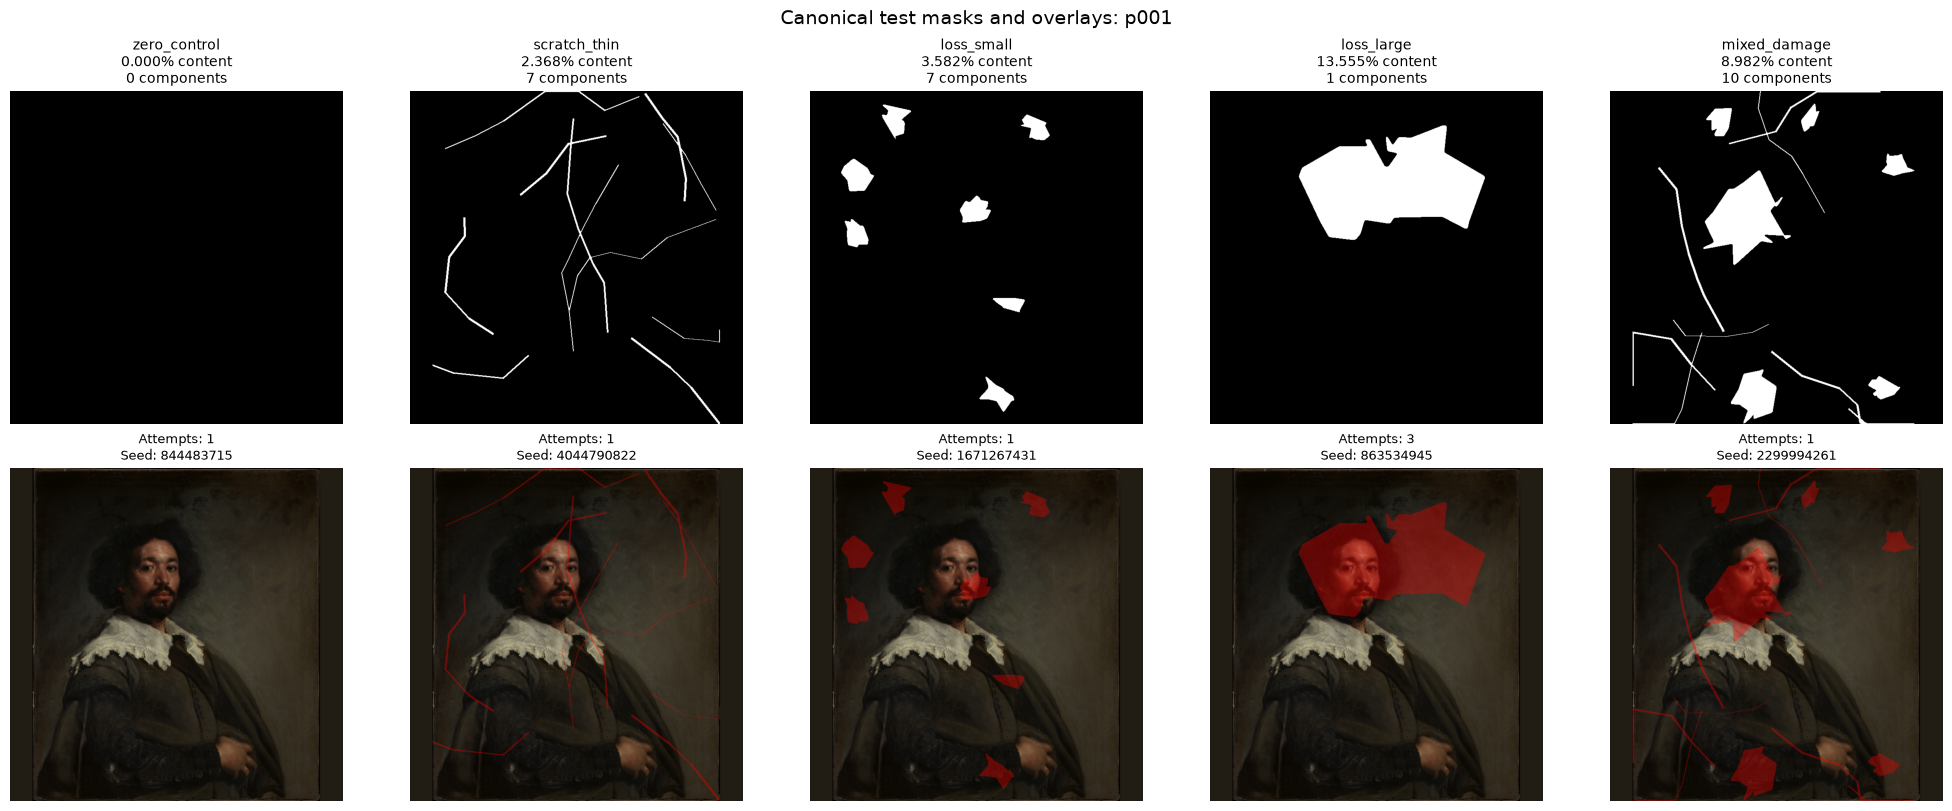

Deterministic replay comparison
-------------------------------


,mask_type,painting_seed_equal,mask_seed_equal,retry_seed_equal,pixel_arrays_equal
0,zero_control,True,True,True,True
1,scratch_thin,True,True,True,True
2,loss_small,True,True,True,True
3,loss_large,True,True,True,True
4,mixed_damage,True,True,True,True



Visual inspection completed.
Deterministic replay passed.


In [9]:
# Visual inspection and deterministic replay of the one-painting test

test_row = test_metadata_df.iloc[0]

processed_image_path = Path(
    str(test_row["processed_path"])
)

if not processed_image_path.is_absolute():
    processed_image_path = (
        PROJECT_ROOT / processed_image_path
    )

if not processed_image_path.exists():
    raise FileNotFoundError(
        f"Processed test image not found: {processed_image_path}"
    )

with Image.open(processed_image_path) as image:
    clean_image = image.convert("RGB")
    clean_image.load()

if clean_image.size != (target_size, target_size):
    raise ValueError(
        "Processed test image has the wrong dimensions: "
        f"{clean_image.size}"
    )

clean_array = np.asarray(clean_image)

ordered_test_masks_df = (
    test_mask_metadata_df
    .set_index("mask_type")
    .reindex(mask_types)
    .reset_index()
)

figure, axes = plt.subplots(
    2,
    len(mask_types),
    figsize=(4 * len(mask_types), 8),
    constrained_layout=True,
)

for column_index, mask_row in ordered_test_masks_df.iterrows():
    mask_path = Path(
        str(mask_row["mask_path"])
    )

    with Image.open(mask_path) as image:
        mask_image = image.convert("L")
        mask_image.load()

    mask_array = np.asarray(mask_image)

    overlay_array = clean_array.copy()
    overlay_array[mask_array > 0] = [255, 0, 0]

    blended_array = (
        0.65 * clean_array
        + 0.35 * overlay_array
    ).astype(np.uint8)

    axes[0, column_index].imshow(
        mask_image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[0, column_index].set_title(
        f"{mask_row['mask_type']}\n"
        f"{mask_row['actual_mask_area_percentage_content']:.3f}% content\n"
        f"{mask_row['connected_component_count']} components",
        fontsize=10,
    )
    axes[0, column_index].axis("off")

    axes[1, column_index].imshow(
        blended_array
    )
    axes[1, column_index].set_title(
        f"Attempts: {mask_row['generation_attempts']}\n"
        f"Seed: {mask_row['mask_seed']}",
        fontsize=9,
    )
    axes[1, column_index].axis("off")

figure.suptitle(
    f"Canonical test masks and overlays: {test_painting_id}",
    fontsize=14,
)

plt.show()

# Generate the same test case again in a separate directory.
replay_mask_dir = logs_dir / "mask_generation_replay"

if replay_mask_dir.exists():
    shutil.rmtree(replay_mask_dir)

replay_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

replay_metadata_df = generate_masks_for_dataset(
    metadata=test_metadata_df,
    mask_dir=replay_mask_dir,
    target_size=target_size,
    mask_types=mask_types,
    base_seed=global_seed,
    mask_specs=mask_specs,
    max_attempts=max_generation_attempts,
    generator_name=generator_name,
    generator_version=generator_version,
    config_version=config_version,
    experiment_name=experiment_name,
    experiment_version=experiment_version,
)

replay_comparison_rows = []

for mask_type in mask_types:
    original_row = test_mask_metadata_df.loc[
        test_mask_metadata_df["mask_type"] == mask_type
    ].iloc[0]

    replay_row = replay_metadata_df.loc[
        replay_metadata_df["mask_type"] == mask_type
    ].iloc[0]

    original_path = Path(
        str(original_row["mask_path"])
    )
    replay_path = Path(
        str(replay_row["mask_path"])
    )

    with Image.open(original_path) as image:
        original_array = np.asarray(
            image.convert("L")
        )

    with Image.open(replay_path) as image:
        replay_array = np.asarray(
            image.convert("L")
        )

    arrays_equal = bool(
        np.array_equal(
            original_array,
            replay_array,
        )
    )

    replay_comparison_rows.append(
        {
            "mask_type": mask_type,
            "painting_seed_equal": (
                int(original_row["painting_seed"])
                == int(replay_row["painting_seed"])
            ),
            "mask_seed_equal": (
                int(original_row["mask_seed"])
                == int(replay_row["mask_seed"])
            ),
            "retry_seed_equal": (
                int(original_row["retry_seed"])
                == int(replay_row["retry_seed"])
            ),
            "pixel_arrays_equal": arrays_equal,
        }
    )

deterministic_replay_df = pd.DataFrame(
    replay_comparison_rows
)

print("Deterministic replay comparison")
print("-------------------------------")
display(deterministic_replay_df)

if not deterministic_replay_df[
    [
        "painting_seed_equal",
        "mask_seed_equal",
        "retry_seed_equal",
        "pixel_arrays_equal",
    ]
].all().all():
    raise ValueError(
        "Deterministic replay failed for one or more masks."
    )

print("\nVisual inspection completed.")
print("Deterministic replay passed.")

In [10]:
# Generate the complete canonical mask set

mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

mask_metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

metrics_dir.mkdir(
    parents=True,
    exist_ok=True,
)

logs_dir.mkdir(
    parents=True,
    exist_ok=True,
)

expected_mask_filenames = {
    f"{painting_id}_{mask_type}_mask.png"
    for painting_id in (
        processed_metadata_df["painting_id"]
        .astype(str)
        .tolist()
    )
    for mask_type in mask_types
}

existing_mask_files_before_generation = sorted(
    path
    for path in mask_dir.glob("*.png")
    if path.is_file()
)

existing_filenames_before_generation = {
    path.name
    for path in existing_mask_files_before_generation
}

unexpected_files_before_generation = sorted(
    existing_filenames_before_generation
    - expected_mask_filenames
)

missing_expected_files_before_generation = sorted(
    expected_mask_filenames
    - existing_filenames_before_generation
)

print("Pre-generation inventory")
print("------------------------")
print(
    "Expected canonical filenames:",
    len(expected_mask_filenames),
)
print(
    "Existing PNG files:",
    len(existing_mask_files_before_generation),
)
print(
    "Unexpected existing PNG files:",
    len(unexpected_files_before_generation),
)
print(
    "Missing expected files before generation:",
    len(missing_expected_files_before_generation),
)

if unexpected_files_before_generation:
    print(
        "\nUnexpected existing files will not be deleted automatically."
    )
    display(
        pd.DataFrame(
            {
                "mask_filename": unexpected_files_before_generation,
                "pre_generation_status": (
                    "unexpected_or_stale_candidate"
                ),
            }
        )
    )

mask_metadata_df = generate_masks_for_dataset(
    metadata=processed_metadata_df,
    mask_dir=mask_dir,
    target_size=target_size,
    mask_types=mask_types,
    base_seed=global_seed,
    mask_specs=mask_specs,
    max_attempts=max_generation_attempts,
    generator_name=generator_name,
    generator_version=generator_version,
    config_version=config_version,
    experiment_name=experiment_name,
    experiment_version=experiment_version,
)

expected_mask_count = (
    len(processed_metadata_df)
    * len(mask_types)
)

print("\nCanonical generation result")
print("---------------------------")
print("Generated metadata rows:", len(mask_metadata_df))
print("Expected rows:", expected_mask_count)
print("Unique paintings:", mask_metadata_df["painting_id"].nunique())
print("Unique cases:", mask_metadata_df["case_id"].nunique())
print("Mask directory:", mask_dir)

print("\nMask-type counts")
display(
    mask_metadata_df["mask_type"]
    .value_counts()
    .reindex(mask_types)
    .rename_axis("mask_type")
    .reset_index(name="count")
)

print("\nGeneration-status counts")
display(
    mask_metadata_df[
        "generation_status"
    ]
    .value_counts(dropna=False)
    .rename_axis("generation_status")
    .reset_index(name="count")
)

print("\nCanonical status counts")
display(
    mask_metadata_df["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

print("\nIssue counts")
display(
    mask_metadata_df["issue"]
    .replace("", "ok")
    .value_counts(dropna=False)
    .rename_axis("issue")
    .reset_index(name="count")
)

generation_preview_columns = [
    "case_id",
    "mask_type",
    "generator_version",
    "global_seed",
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "target_area_pct",
    "actual_mask_area_percentage_content",
    "generation_attempts",
    "connected_component_count",
    "bbox_fill_ratio",
    "padding_overlap_pixels",
    "generation_valid",
]

display(
    mask_metadata_df[
        generation_preview_columns
    ].head(10)
)

if len(mask_metadata_df) != expected_mask_count:
    raise ValueError(
        f"Expected {expected_mask_count} mask records, "
        f"generated {len(mask_metadata_df)}."
    )

if mask_metadata_df["case_id"].nunique() != expected_mask_count:
    raise ValueError(
        "Generated mask metadata contains duplicate case IDs."
    )

if not mask_metadata_df["generation_valid"].all():
    display(
        mask_metadata_df[
            ~mask_metadata_df["generation_valid"]
        ]
    )
    raise ValueError(
        "At least one generated mask failed canonical generation checks."
    )

print("\nCanonical mask generation completed successfully.")

Pre-generation inventory
------------------------
Expected canonical filenames: 250
Existing PNG files: 250
Unexpected existing PNG files: 0
Missing expected files before generation: 0

Canonical generation result
---------------------------
Generated metadata rows: 250
Expected rows: 250
Unique paintings: 50
Unique cases: 250
Mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks

Mask-type counts


,mask_type,count
0,zero_control,50
1,scratch_thin,50
2,loss_small,50
3,loss_large,50
4,mixed_damage,50



Generation-status counts


,generation_status,count
0,ok,250



Canonical status counts


,status,count
0,ok,250



Issue counts


,issue,count
0,ok,250


,case_id,mask_type,generator_version,global_seed,painting_seed,mask_seed,retry_seed,target_area_pct,actual_mask_area_percentage_content,generation_attempts,connected_component_count,bbox_fill_ratio,padding_overlap_pixels,generation_valid
0,p001_zero_control,zero_control,2.0.0,20260630,1049792242,844483715,887186148,0.0,0.000000,1,0,0.000000,0,True
1,p001_scratch_thin,scratch_thin,2.0.0,20260630,1049792242,4044790822,2328332586,2.0,2.368103,1,7,0.023681,0,True
2,p001_loss_small,loss_small,2.0.0,20260630,1049792242,1671267431,4093361246,4.5,3.582006,1,7,0.053482,0,True
3,p001_loss_large,loss_large,2.0.0,20260630,1049792242,863534945,465719629,12.5,13.554629,3,1,0.609398,0,True
4,p001_mixed_damage,mixed_damage,2.0.0,20260630,1049792242,2299994261,3833033610,11.5,8.981626,1,10,0.091613,0,True
5,p002_zero_control,zero_control,2.0.0,20260630,2652208543,3431267103,796384237,0.0,0.000000,1,0,0.000000,0,True
6,p002_scratch_thin,scratch_thin,2.0.0,20260630,2652208543,339112385,4187836088,2.0,2.783674,2,4,0.028851,0,True
7,p002_loss_small,loss_small,2.0.0,20260630,2652208543,1946636804,991765720,4.5,5.444970,1,7,0.088312,0,True
8,p002_loss_large,loss_large,2.0.0,20260630,2652208543,3331775940,835546425,12.5,10.857171,5,1,0.597742,0,True
9,p002_mixed_damage,mixed_damage,2.0.0,20260630,2652208543,747555413,1598298252,11.5,10.018212,1,4,0.100182,0,True



Canonical mask generation completed successfully.


In [11]:
# Save and verify canonical mask metadata

mask_metadata_df.to_csv(
    mask_metadata_path,
    index=False,
)

print("Mask metadata saved")
print("-------------------")
print("Path:", mask_metadata_path)
print("Exists:", mask_metadata_path.exists())
print("Rows:", len(mask_metadata_df))
print("Columns:", len(mask_metadata_df.columns))
print("File size:", mask_metadata_path.stat().st_size, "bytes")

reloaded_mask_metadata_df = pd.read_csv(
    mask_metadata_path
)

print("\nReload verification")
print("-------------------")
print("Reloaded shape:", reloaded_mask_metadata_df.shape)
print(
    "Case IDs preserved:",
    reloaded_mask_metadata_df["case_id"].tolist()
    == mask_metadata_df["case_id"].tolist(),
)
print(
    "Mask filenames preserved:",
    reloaded_mask_metadata_df["mask_filename"].tolist()
    == mask_metadata_df["mask_filename"].tolist(),
)

required_mask_metadata_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_filename",
    "mask_path",
    "generator_name",
    "generator_version",
    "config_version",
    "experiment_name",
    "experiment_version",
    "global_seed",
    "painting_seed",
    "mask_seed",
    "retry_seed",
    "target_area_pct",
    "target_area_min_pct",
    "target_area_max_pct",
    "actual_mask_area_pixels",
    "damaged_content_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
    "padding_overlap_pixels",
    "bbox_x_min",
    "bbox_y_min",
    "bbox_x_max",
    "bbox_y_max",
    "bbox_width",
    "bbox_height",
    "bbox_area_pixels",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
    "connected_component_count",
    "largest_component_pixels",
    "mean_component_pixels",
    "largest_component_fraction",
    "component_density_per_100k_content_pixels",
    "touches_content_border",
    "minimum_distance_to_content_border_pixels",
    "generation_attempts",
    "accepted_attempt",
    "area_distance_to_target_pct",
    "area_distance_to_allowed_range_pct",
    "binary_values_valid",
    "zero_control_rule_valid",
    "content_only_valid",
    "area_within_target_tolerance",
    "generation_valid",
    "status",
    "issue",
]

missing_mask_metadata_columns = [
    column
    for column in required_mask_metadata_columns
    if column not in reloaded_mask_metadata_df.columns
]

if missing_mask_metadata_columns:
    raise ValueError(
        "Reloaded mask metadata is missing required columns: "
        f"{missing_mask_metadata_columns}"
    )

if reloaded_mask_metadata_df.shape != mask_metadata_df.shape:
    raise ValueError(
        "Reloaded mask metadata shape does not match "
        "the in-memory metadata."
    )

if (
    reloaded_mask_metadata_df["case_id"].tolist()
    != mask_metadata_df["case_id"].tolist()
):
    raise ValueError(
        "Case-ID ordering changed after metadata reload."
    )

if (
    reloaded_mask_metadata_df["mask_filename"].tolist()
    != mask_metadata_df["mask_filename"].tolist()
):
    raise ValueError(
        "Mask filenames changed after metadata reload."
    )

if (
    reloaded_mask_metadata_df["generator_version"]
    .astype(str)
    .ne(generator_version)
    .any()
):
    raise ValueError(
        "Reloaded metadata contains an unexpected generator version."
    )

mask_metadata_df = reloaded_mask_metadata_df.copy()

print("\nCanonical metadata save/reload verification passed.")
display(mask_metadata_df.head())

Mask metadata saved
-------------------
Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Exists: True
Rows: 250
Columns: 66
File size: 139074 bytes

Reload verification
-------------------
Reloaded shape: (250, 66)
Case IDs preserved: True
Mask filenames preserved: True

Canonical metadata save/reload verification passed.


,case_id,painting_id,mask_id,mask_type,mask_type_index,mask_filename,mask_path,generator_name,generator_version,config_version,...,area_distance_to_allowed_range_pct,area_within_target_tolerance,generation_status,unique_pixel_values,binary_values_valid,zero_control_rule_valid,content_only_valid,generation_valid,status,issue
0,p001_zero_control,p001,p001_zero_control,zero_control,0,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0,True,True,True,True,ok,NaN
1,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,1,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
2,p001_loss_small,p001,p001_loss_small,loss_small,2,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
3,p001_loss_large,p001,p001_loss_large,loss_large,3,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
4,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,4,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN


In [12]:
# Validate canonical saved mask files against their metadata

mask_validation_df = validate_masks(
    mask_metadata=mask_metadata_df,
    target_size=target_size,
)

print("Saved-mask validation")
print("---------------------")
print("Rows checked:", len(mask_validation_df))
print(
    "Files present:",
    int(mask_validation_df["file_exists"].sum()),
)
print(
    "Readable files:",
    int(mask_validation_df["readable"].sum()),
)
print(
    "Validation passes:",
    int(mask_validation_df["validation_passed"].sum()),
)
print(
    "Validation failures:",
    int((~mask_validation_df["validation_passed"]).sum()),
)

print("\nValidation issue counts")
display(
    mask_validation_df["issue"]
    .replace("", "ok")
    .value_counts(dropna=False)
    .rename_axis("issue")
    .reset_index(name="count")
)

failed_mask_validation_df = mask_validation_df[
    ~mask_validation_df["validation_passed"]
].copy()

if not failed_mask_validation_df.empty:
    display(failed_mask_validation_df)
    raise ValueError(
        "One or more saved mask files failed canonical validation."
    )

pixel_count_match = np.array_equal(
    mask_validation_df[
        "recalculated_mask_area_pixels"
    ].astype(int).to_numpy(),
    mask_metadata_df[
        "actual_mask_area_pixels"
    ].astype(int).to_numpy(),
)

content_percentage_match = np.allclose(
    mask_validation_df[
        "recalculated_mask_area_percentage_content"
    ].astype(float).to_numpy(),
    mask_metadata_df[
        "actual_mask_area_percentage_content"
    ].astype(float).to_numpy(),
    atol=1e-4,
)

padding_overlap_match = np.array_equal(
    mask_validation_df[
        "recalculated_padding_overlap_pixels"
    ].astype(int).to_numpy(),
    mask_metadata_df[
        "padding_overlap_pixels"
    ].astype(int).to_numpy(),
)

print("\nMetadata consistency")
print("--------------------")
print("Pixel counts match:", pixel_count_match)
print("Content percentages match:", content_percentage_match)
print("Padding-overlap counts match:", padding_overlap_match)

if not pixel_count_match:
    raise ValueError(
        "Stored and recalculated damaged-pixel counts differ."
    )

if not content_percentage_match:
    raise ValueError(
        "Stored and recalculated content percentages differ."
    )

if not padding_overlap_match:
    raise ValueError(
        "Stored and recalculated padding-overlap counts differ."
    )

print("\nAll canonical mask files passed validation.")

Saved-mask validation
---------------------
Rows checked: 250
Files present: 250
Readable files: 250
Validation passes: 250
Validation failures: 0

Validation issue counts


,issue,count
0,ok,250



Metadata consistency
--------------------
Pixel counts match: True
Content percentages match: True
Padding-overlap counts match: True

All canonical mask files passed validation.


In [13]:
# Experimental completeness, duplication, and inventory audit

inventory_audit = audit_mask_inventory(
    mask_metadata=mask_metadata_df,
    mask_dir=mask_dir,
    expected_mask_types=mask_types,
)

inventory_audit_summary_rows = []

for audit_name, audit_df in inventory_audit.items():
    inventory_audit_summary_rows.append(
        {
            "audit": audit_name,
            "issue_rows": len(audit_df),
            "passed": len(audit_df) == 0,
        }
    )

inventory_audit_summary_df = pd.DataFrame(
    inventory_audit_summary_rows
)

print("Inventory audit")
print("---------------")
display(inventory_audit_summary_df)

for audit_name, audit_df in inventory_audit.items():
    if not audit_df.empty:
        print(f"\n{audit_name}")
        display(audit_df)

mask_count_matrix = (
    mask_metadata_df
    .groupby(
        ["painting_id", "mask_type"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=mask_types, fill_value=0)
)

invalid_mask_count_rows = mask_count_matrix[
    (mask_count_matrix != 1).any(axis=1)
]

zero_control_df = mask_metadata_df[
    mask_metadata_df["mask_type"] == "zero_control"
].copy()

nonzero_mask_df = mask_metadata_df[
    mask_metadata_df["mask_type"] != "zero_control"
].copy()

invalid_zero_control_rows = zero_control_df[
    zero_control_df["actual_mask_area_pixels"] != 0
]

invalid_nonzero_rows = nonzero_mask_df[
    nonzero_mask_df["actual_mask_area_pixels"] <= 0
]

outside_area_tolerance_rows = mask_metadata_df[
    ~mask_metadata_df["area_within_target_tolerance"]
]

padding_overlap_rows = mask_metadata_df[
    mask_metadata_df["padding_overlap_pixels"] != 0
]

nonbinary_rows = mask_metadata_df[
    ~mask_metadata_df["binary_values_valid"]
]

wrong_generator_rows = mask_metadata_df[
    (
        mask_metadata_df["generator_name"]
        .astype(str)
        != generator_name
    )
    | (
        mask_metadata_df["generator_version"]
        .astype(str)
        != generator_version
    )
]

expected_seed_uniqueness = (
    mask_metadata_df["mask_seed"].nunique()
    == len(mask_metadata_df)
)

print("\nExperimental audit")
print("------------------")
print("Expected masks:", expected_mask_count)
print("Actual masks:", len(mask_metadata_df))
print(
    "Paintings with missing or duplicate mask types:",
    len(invalid_mask_count_rows),
)
print(
    "Invalid zero controls:",
    len(invalid_zero_control_rows),
)
print(
    "Empty non-zero masks:",
    len(invalid_nonzero_rows),
)
print(
    "Outside target-area tolerance:",
    len(outside_area_tolerance_rows),
)
print(
    "Padding-overlap masks:",
    len(padding_overlap_rows),
)
print(
    "Non-binary metadata flags:",
    len(nonbinary_rows),
)
print(
    "Wrong generator/version rows:",
    len(wrong_generator_rows),
)
print(
    "Unique mask seed per case:",
    expected_seed_uniqueness,
)

audit_failures = {
    "wrong_total_count": (
        len(mask_metadata_df) != expected_mask_count
    ),
    "invalid_mask_count_matrix": (
        not invalid_mask_count_rows.empty
    ),
    "invalid_zero_controls": (
        not invalid_zero_control_rows.empty
    ),
    "invalid_nonzero_masks": (
        not invalid_nonzero_rows.empty
    ),
    "outside_area_tolerance": (
        not outside_area_tolerance_rows.empty
    ),
    "padding_overlap": (
        not padding_overlap_rows.empty
    ),
    "nonbinary_masks": (
        not nonbinary_rows.empty
    ),
    "wrong_generator_version": (
        not wrong_generator_rows.empty
    ),
    "duplicate_mask_seeds": (
        not expected_seed_uniqueness
    ),
    "inventory_audit_failure": (
        not inventory_audit_summary_df["passed"].all()
    ),
}

failed_audits = [
    audit_name
    for audit_name, failed in audit_failures.items()
    if failed
]

if failed_audits:
    if not invalid_mask_count_rows.empty:
        display(invalid_mask_count_rows)

    if not outside_area_tolerance_rows.empty:
        display(outside_area_tolerance_rows)

    if not padding_overlap_rows.empty:
        display(padding_overlap_rows)

    raise ValueError(
        "Canonical mask audit failed: "
        f"{failed_audits}"
    )

print("\nAll experimental and inventory audits passed.")

Inventory audit
---------------


,audit,issue_rows,passed
0,duplicate_case_rows,0,True
1,duplicate_mask_id_rows,0,True
2,duplicate_filename_rows,0,True
3,duplicate_path_rows,0,True
4,missing_file_rows,0,True
5,orphan_file_rows,0,True
6,missing_mask_type_rows,0,True
7,unexpected_mask_type_rows,0,True



Experimental audit
------------------
Expected masks: 250
Actual masks: 250
Paintings with missing or duplicate mask types: 0
Invalid zero controls: 0
Empty non-zero masks: 0
Outside target-area tolerance: 0
Padding-overlap masks: 0
Non-binary metadata flags: 0
Wrong generator/version rows: 0
Unique mask seed per case: True

All experimental and inventory audits passed.


In [14]:
# Build canonical mask-generation summary tables

nonzero_mask_metadata_df = mask_metadata_df[
    mask_metadata_df["mask_type"] != "zero_control"
].copy()

# ---------------------------------------------------------------------
# Area summary
# ---------------------------------------------------------------------

area_summary_df = (
    mask_metadata_df
    .groupby("mask_type", sort=False)
    .agg(
        count=(
            "case_id",
            "count",
        ),
        target_area_pct=(
            "target_area_pct",
            "first",
        ),
        target_area_min_pct=(
            "target_area_min_pct",
            "first",
        ),
        target_area_max_pct=(
            "target_area_max_pct",
            "first",
        ),
        mean_actual_area_pct=(
            "actual_mask_area_percentage_content",
            "mean",
        ),
        std_actual_area_pct=(
            "actual_mask_area_percentage_content",
            "std",
        ),
        min_actual_area_pct=(
            "actual_mask_area_percentage_content",
            "min",
        ),
        max_actual_area_pct=(
            "actual_mask_area_percentage_content",
            "max",
        ),
        mean_area_error_pct=(
            "area_distance_to_target_pct",
            "mean",
        ),
        max_area_error_pct=(
            "area_distance_to_target_pct",
            "max",
        ),
        mean_actual_area_pixels=(
            "actual_mask_area_pixels",
            "mean",
        ),
    )
    .reindex(mask_types)
    .reset_index()
)

area_summary_df["std_actual_area_pct"] = (
    area_summary_df["std_actual_area_pct"]
    .fillna(0.0)
)

area_numeric_columns = [
    "target_area_pct",
    "target_area_min_pct",
    "target_area_max_pct",
    "mean_actual_area_pct",
    "std_actual_area_pct",
    "min_actual_area_pct",
    "max_actual_area_pct",
    "mean_area_error_pct",
    "max_area_error_pct",
    "mean_actual_area_pixels",
]

area_summary_df[area_numeric_columns] = (
    area_summary_df[area_numeric_columns]
    .round(4)
)

# ---------------------------------------------------------------------
# Connected-component summary
# ---------------------------------------------------------------------

component_summary_df = (
    mask_metadata_df
    .groupby("mask_type", sort=False)
    .agg(
        count=(
            "case_id",
            "count",
        ),
        mean_connected_components=(
            "connected_component_count",
            "mean",
        ),
        median_connected_components=(
            "connected_component_count",
            "median",
        ),
        min_connected_components=(
            "connected_component_count",
            "min",
        ),
        max_connected_components=(
            "connected_component_count",
            "max",
        ),
        mean_largest_component_pixels=(
            "largest_component_pixels",
            "mean",
        ),
        mean_component_pixels=(
            "mean_component_pixels",
            "mean",
        ),
        mean_largest_component_fraction=(
            "largest_component_fraction",
            "mean",
        ),
        mean_component_density=(
            "component_density_per_100k_content_pixels",
            "mean",
        ),
        mean_component_aspect_ratio=(
            "mean_component_aspect_ratio",
            "mean",
        ),
        maximum_component_aspect_ratio=(
            "maximum_component_aspect_ratio",
            "max",
        ),
    )
    .reindex(mask_types)
    .reset_index()
)

component_numeric_columns = [
    column
    for column in component_summary_df.columns
    if column not in {"mask_type", "count"}
]

component_summary_df[component_numeric_columns] = (
    component_summary_df[component_numeric_columns]
    .round(4)
)

# ---------------------------------------------------------------------
# Bounding-box and border summary
# ---------------------------------------------------------------------

bbox_summary_df = (
    mask_metadata_df
    .groupby("mask_type", sort=False)
    .agg(
        count=(
            "case_id",
            "count",
        ),
        mean_bbox_area_pixels=(
            "bbox_area_pixels",
            "mean",
        ),
        mean_bbox_width=(
            "bbox_width",
            "mean",
        ),
        mean_bbox_height=(
            "bbox_height",
            "mean",
        ),
        mean_bbox_fill_ratio=(
            "bbox_fill_ratio",
            "mean",
        ),
        mean_bbox_aspect_ratio=(
            "bbox_aspect_ratio",
            "mean",
        ),
        mean_minimum_distance_to_border_pixels=(
            "minimum_distance_to_content_border_pixels",
            "mean",
        ),
        touching_border_count=(
            "touches_content_border",
            "sum",
        ),
        touching_border_percentage=(
            "touches_content_border",
            "mean",
        ),
    )
    .reindex(mask_types)
    .reset_index()
)

bbox_summary_df["touching_border_percentage"] = (
    bbox_summary_df["touching_border_percentage"]
    * 100.0
)

bbox_numeric_columns = [
    column
    for column in bbox_summary_df.columns
    if column not in {
        "mask_type",
        "count",
        "touching_border_count",
    }
]

bbox_summary_df[bbox_numeric_columns] = (
    bbox_summary_df[bbox_numeric_columns]
    .round(4)
)

# ---------------------------------------------------------------------
# Validation summary
# ---------------------------------------------------------------------

validation_by_case_df = mask_metadata_df[
    [
        "case_id",
        "mask_type",
        "generation_valid",
        "binary_values_valid",
        "content_only_valid",
        "area_within_target_tolerance",
        "padding_overlap_pixels",
    ]
].merge(
    mask_validation_df[
        [
            "case_id",
            "validation_passed",
            "issue_count",
        ]
    ],
    on="case_id",
    how="left",
    validate="one_to_one",
)

validation_summary_df = (
    validation_by_case_df
    .groupby("mask_type", sort=False)
    .agg(
        count=(
            "case_id",
            "count",
        ),
        generation_success_count=(
            "generation_valid",
            "sum",
        ),
        saved_file_validation_success_count=(
            "validation_passed",
            "sum",
        ),
        binary_success_count=(
            "binary_values_valid",
            "sum",
        ),
        content_only_success_count=(
            "content_only_valid",
            "sum",
        ),
        area_tolerance_success_count=(
            "area_within_target_tolerance",
            "sum",
        ),
        padding_overlap_mask_count=(
            "padding_overlap_pixels",
            lambda values: int((values > 0).sum()),
        ),
        total_validation_issues=(
            "issue_count",
            "sum",
        ),
    )
    .reindex(mask_types)
    .reset_index()
)

validation_summary_df["generation_success_percentage"] = (
    validation_summary_df["generation_success_count"]
    / validation_summary_df["count"]
    * 100.0
)

validation_summary_df[
    "saved_file_validation_success_percentage"
] = (
    validation_summary_df[
        "saved_file_validation_success_count"
    ]
    / validation_summary_df["count"]
    * 100.0
)

validation_summary_df["binary_success_percentage"] = (
    validation_summary_df["binary_success_count"]
    / validation_summary_df["count"]
    * 100.0
)

validation_summary_df["content_only_success_percentage"] = (
    validation_summary_df["content_only_success_count"]
    / validation_summary_df["count"]
    * 100.0
)

validation_summary_df["area_tolerance_success_percentage"] = (
    validation_summary_df["area_tolerance_success_count"]
    / validation_summary_df["count"]
    * 100.0
)

percentage_columns = [
    column
    for column in validation_summary_df.columns
    if column.endswith("_percentage")
]

validation_summary_df[percentage_columns] = (
    validation_summary_df[percentage_columns]
    .round(2)
)

# ---------------------------------------------------------------------
# Generation-attempt summary
# ---------------------------------------------------------------------

generation_statistics_df = (
    mask_metadata_df
    .groupby("mask_type", sort=False)
    .agg(
        count=(
            "case_id",
            "count",
        ),
        mean_generation_attempts=(
            "generation_attempts",
            "mean",
        ),
        median_generation_attempts=(
            "generation_attempts",
            "median",
        ),
        min_generation_attempts=(
            "generation_attempts",
            "min",
        ),
        max_generation_attempts=(
            "generation_attempts",
            "max",
        ),
        first_attempt_success_count=(
            "generation_attempts",
            lambda values: int((values == 1).sum()),
        ),
        retry_required_count=(
            "generation_attempts",
            lambda values: int((values > 1).sum()),
        ),
        generation_warning_count=(
            "generation_valid",
            lambda values: int((~values.astype(bool)).sum()),
        ),
    )
    .reindex(mask_types)
    .reset_index()
)

generation_statistics_df[
    "first_attempt_success_percentage"
] = (
    generation_statistics_df["first_attempt_success_count"]
    / generation_statistics_df["count"]
    * 100.0
)

generation_statistics_df[
    "retry_required_percentage"
] = (
    generation_statistics_df["retry_required_count"]
    / generation_statistics_df["count"]
    * 100.0
)

generation_statistics_df[
    [
        "mean_generation_attempts",
        "median_generation_attempts",
        "first_attempt_success_percentage",
        "retry_required_percentage",
    ]
] = (
    generation_statistics_df[
        [
            "mean_generation_attempts",
            "median_generation_attempts",
            "first_attempt_success_percentage",
            "retry_required_percentage",
        ]
    ]
    .round(4)
)

print("Area summary")
print("------------")
display(area_summary_df)

print("\nConnected-component summary")
print("---------------------------")
display(component_summary_df)

print("\nBounding-box and border summary")
print("-------------------------------")
display(bbox_summary_df)

print("\nValidation summary")
print("------------------")
display(validation_summary_df)

print("\nGeneration-attempt statistics")
print("-----------------------------")
display(generation_statistics_df)

Area summary
------------


,mask_type,count,target_area_pct,target_area_min_pct,target_area_max_pct,mean_actual_area_pct,std_actual_area_pct,min_actual_area_pct,max_actual_area_pct,mean_area_error_pct,max_area_error_pct,mean_actual_area_pixels
0,zero_control,50,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00
1,scratch_thin,50,2.0,1.0,3.0,2.1363,0.4984,1.1081,2.9782,0.4296,0.9782,9614.46
2,loss_small,50,4.5,3.0,6.0,4.0246,0.6469,3.0869,5.5021,0.6743,1.4131,18175.36
3,loss_large,50,12.5,10.0,15.0,12.3288,1.3686,10.1506,14.9143,1.1736,2.4143,56236.98
4,mixed_damage,50,11.5,8.0,15.0,9.6600,1.3449,8.0840,13.2845,2.0755,3.4160,43420.00



Connected-component summary
---------------------------


,mask_type,count,mean_connected_components,median_connected_components,min_connected_components,max_connected_components,mean_largest_component_pixels,mean_component_pixels,mean_largest_component_fraction,mean_component_density,mean_component_aspect_ratio,maximum_component_aspect_ratio
0,zero_control,50,0.00,0.0,0,0,0.00,0.0000,0.0000,0.0000,0.0000,0.0000
1,scratch_thin,50,6.10,6.0,3,11,4513.02,1711.5577,0.4696,1.3490,2.8847,29.7000
2,loss_small,50,5.94,6.0,3,8,4584.96,3137.2034,0.2563,1.3177,1.2246,2.7576
3,loss_large,50,1.12,1.0,1,2,51888.38,51717.4100,0.9423,0.2453,1.1487,1.6250
4,mixed_damage,50,8.08,8.0,3,13,27038.26,5938.0126,0.6221,1.7741,2.5839,241.0000



Bounding-box and border summary
-------------------------------


,mask_type,count,mean_bbox_area_pixels,mean_bbox_width,mean_bbox_height,mean_bbox_fill_ratio,mean_bbox_aspect_ratio,mean_minimum_distance_to_border_pixels,touching_border_count,touching_border_percentage
0,zero_control,50,0.00,0.00,0.00,0.0000,0.0000,NaN,0,0.0
1,scratch_thin,50,430884.98,677.00,645.60,0.0226,1.3101,0.00,50,100.0
2,loss_small,50,250862.36,510.04,495.64,0.0791,1.4187,31.10,0,0.0
3,loss_large,50,105826.78,325.00,321.62,0.5605,1.2031,59.68,0,0.0
4,mixed_damage,50,441638.88,687.48,652.68,0.0996,1.3153,0.00,50,100.0



Validation summary
------------------


,mask_type,count,generation_success_count,saved_file_validation_success_count,binary_success_count,content_only_success_count,area_tolerance_success_count,padding_overlap_mask_count,total_validation_issues,generation_success_percentage,saved_file_validation_success_percentage,binary_success_percentage,content_only_success_percentage,area_tolerance_success_percentage
0,zero_control,50,50,50,50,50,50,0,0,100.0,100.0,100.0,100.0,100.0
1,scratch_thin,50,50,50,50,50,50,0,0,100.0,100.0,100.0,100.0,100.0
2,loss_small,50,50,50,50,50,50,0,0,100.0,100.0,100.0,100.0,100.0
3,loss_large,50,50,50,50,50,50,0,0,100.0,100.0,100.0,100.0,100.0
4,mixed_damage,50,50,50,50,50,50,0,0,100.0,100.0,100.0,100.0,100.0



Generation-attempt statistics
-----------------------------


,mask_type,count,mean_generation_attempts,median_generation_attempts,min_generation_attempts,max_generation_attempts,first_attempt_success_count,retry_required_count,generation_warning_count,first_attempt_success_percentage,retry_required_percentage
0,zero_control,50,1.00,1.0,1,1,50,0,0,100.0,0.0
1,scratch_thin,50,1.32,1.0,1,4,39,11,0,78.0,22.0
2,loss_small,50,1.42,1.0,1,5,35,15,0,70.0,30.0
3,loss_large,50,3.46,2.0,1,24,19,31,0,38.0,62.0
4,mixed_damage,50,1.78,1.0,1,24,39,11,0,78.0,22.0


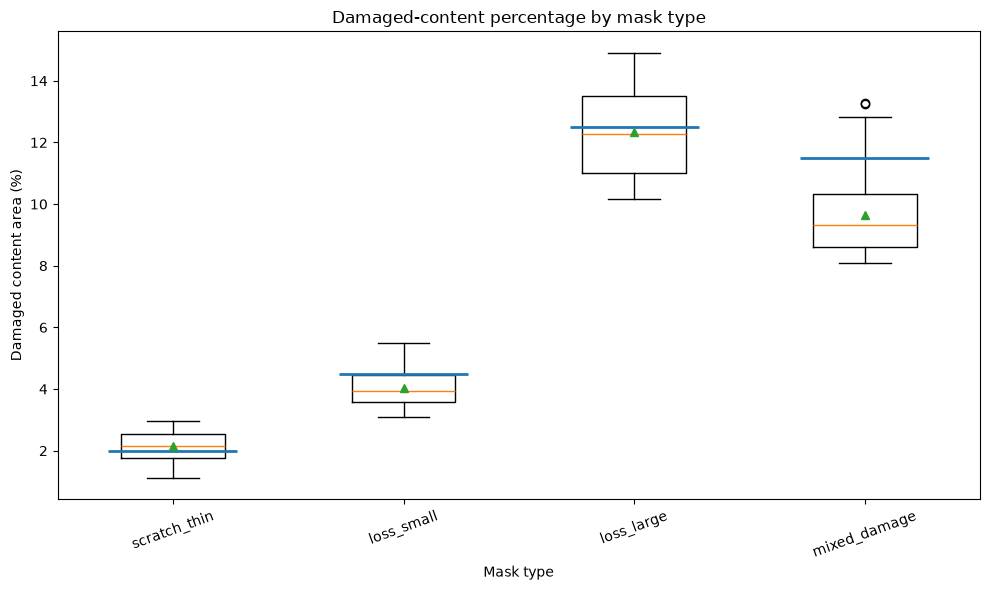

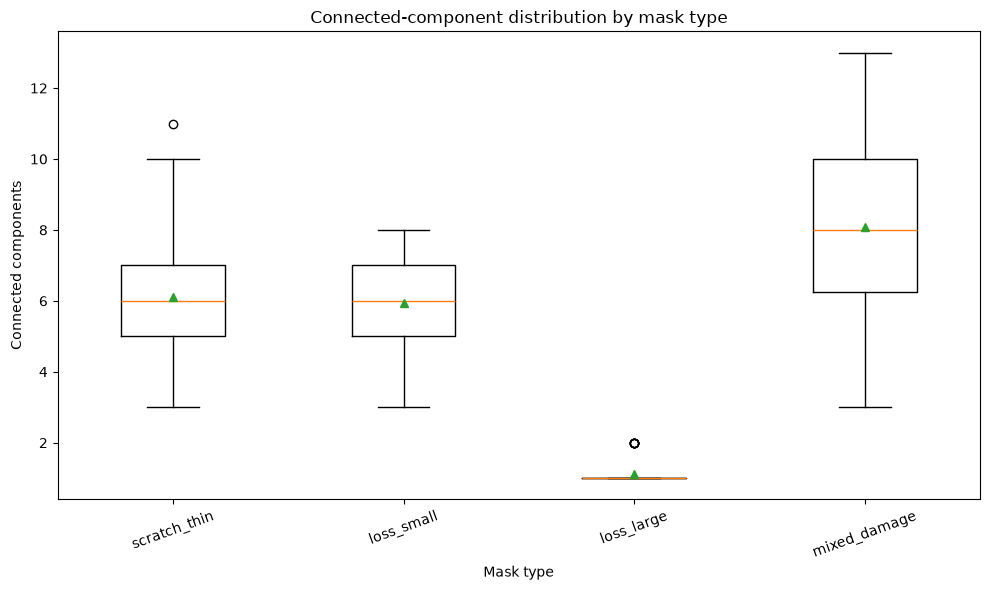

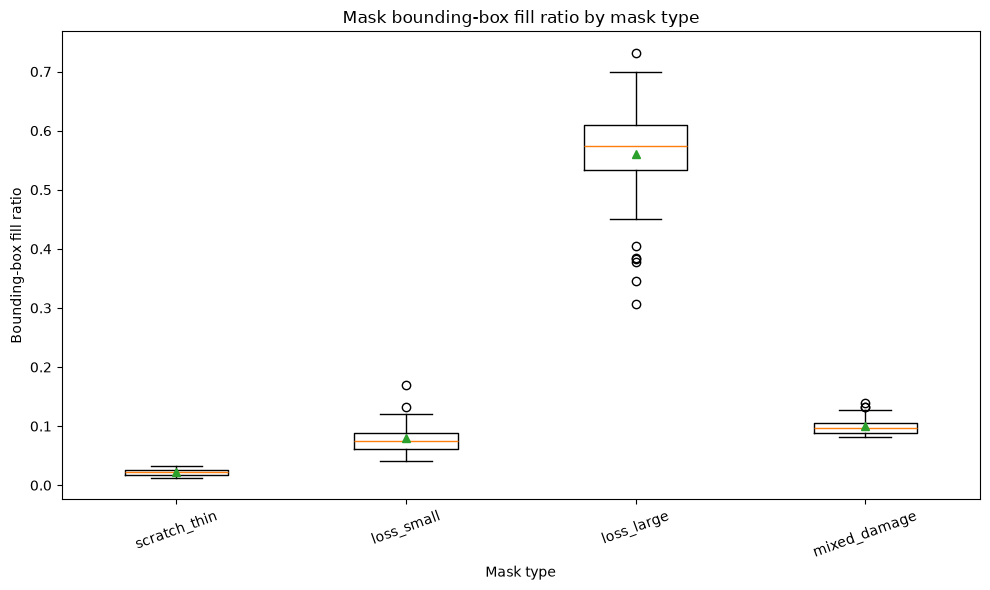

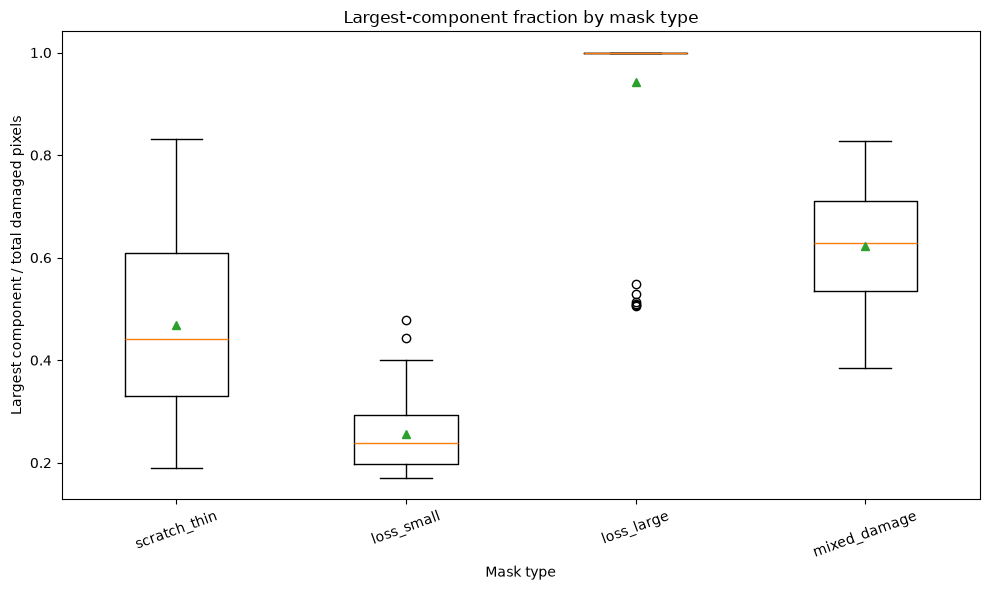

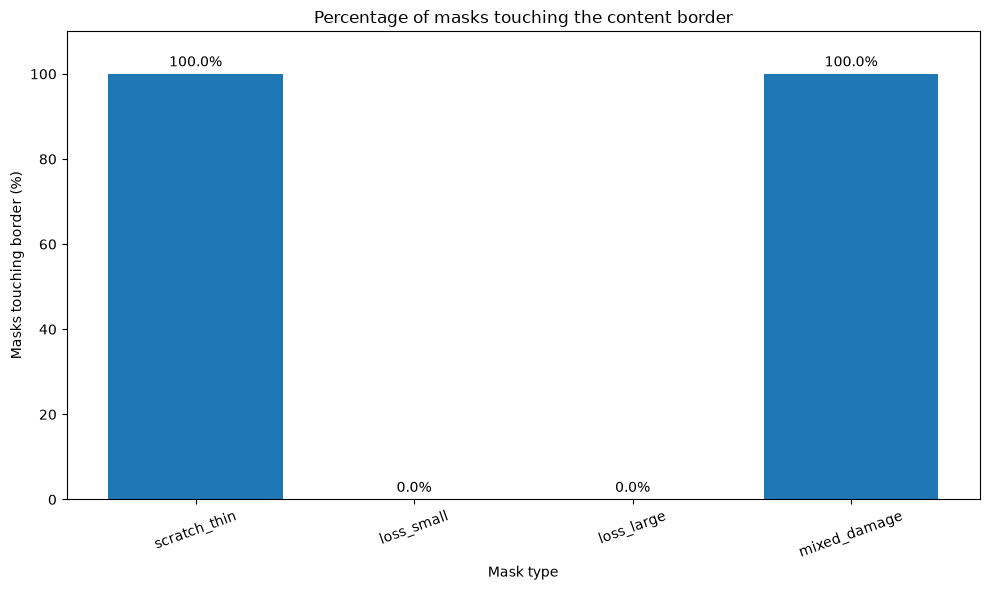

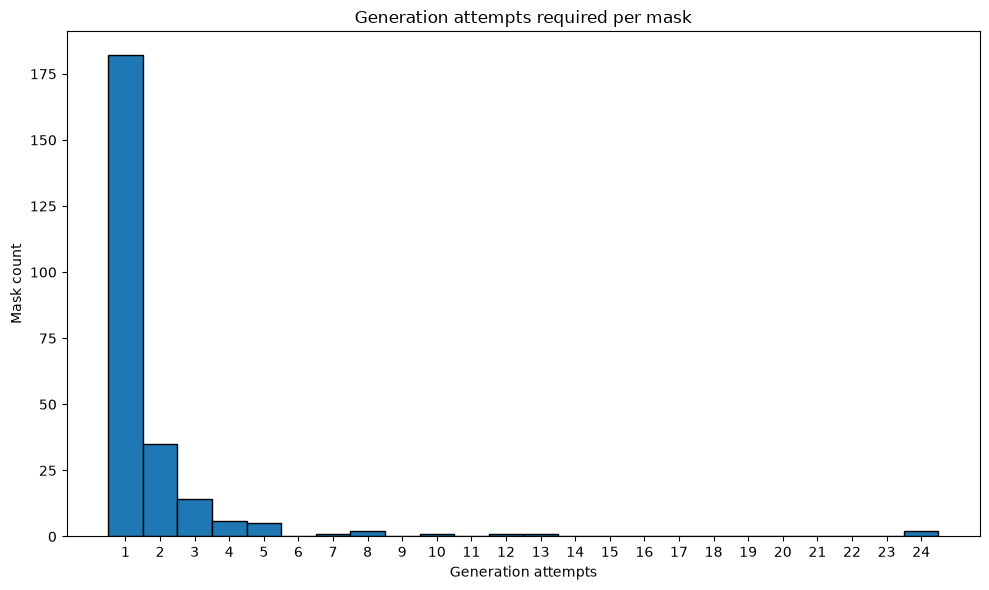

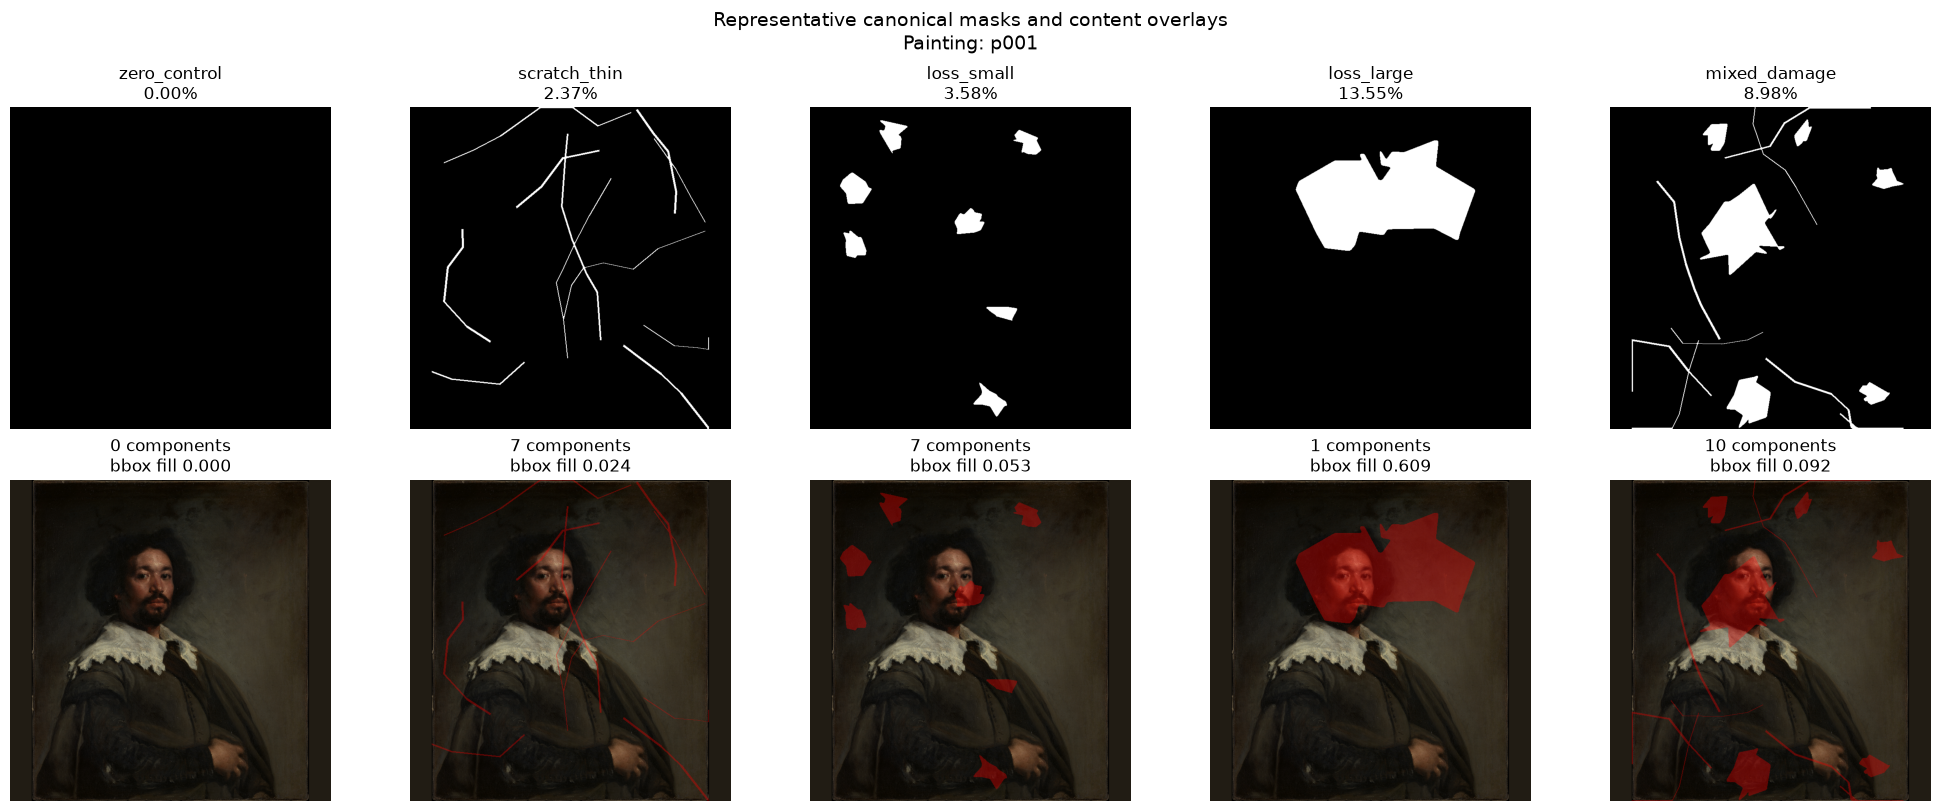

Generated mask figures
----------------------
outputs\figures\masks\mask_area_percentage_distribution.png - True
outputs\figures\masks\mask_connected_component_distribution.png - True
outputs\figures\masks\mask_bbox_fill_ratio_distribution.png - True
outputs\figures\masks\mask_largest_component_fraction_distribution.png - True
outputs\figures\masks\mask_border_touch_percentage.png - True
outputs\figures\masks\mask_generation_attempts_histogram.png - True
outputs\figures\masks\p001_canonical_mask_overlays.png - True


In [15]:
# Generate canonical mask-analysis figures and representative overlays

mask_figure_dir = (
    PROJECT_ROOT
    / paths_cfg["figures_dir"]
    / "masks"
)

mask_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plot_mask_types = [
    mask_type
    for mask_type in mask_types
    if mask_type != "zero_control"
]

# ---------------------------------------------------------------------
# Figure 1: damaged-content percentage distribution
# ---------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6)
)

area_plot_data = [
    mask_metadata_df.loc[
        mask_metadata_df["mask_type"] == mask_type,
        "actual_mask_area_percentage_content",
    ].to_numpy()
    for mask_type in plot_mask_types
]

axis.boxplot(
    area_plot_data,
    tick_labels=plot_mask_types,
    showmeans=True,
)

for position, mask_type in enumerate(
    plot_mask_types,
    start=1,
):
    mask_type_row = area_summary_df.loc[
        area_summary_df["mask_type"] == mask_type
    ].iloc[0]

    axis.hlines(
        y=float(mask_type_row["target_area_pct"]),
        xmin=position - 0.28,
        xmax=position + 0.28,
        linewidth=2,
    )

axis.set_title(
    "Damaged-content percentage by mask type"
)
axis.set_xlabel("Mask type")
axis.set_ylabel("Damaged content area (%)")
axis.tick_params(
    axis="x",
    rotation=20,
)

figure.tight_layout()

area_distribution_path = (
    mask_figure_dir
    / "mask_area_percentage_distribution.png"
)

figure.savefig(
    area_distribution_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------
# Figure 2: connected-component distribution
# ---------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6)
)

component_plot_data = [
    mask_metadata_df.loc[
        mask_metadata_df["mask_type"] == mask_type,
        "connected_component_count",
    ].to_numpy()
    for mask_type in plot_mask_types
]

axis.boxplot(
    component_plot_data,
    tick_labels=plot_mask_types,
    showmeans=True,
)

axis.set_title(
    "Connected-component distribution by mask type"
)
axis.set_xlabel("Mask type")
axis.set_ylabel("Connected components")
axis.tick_params(
    axis="x",
    rotation=20,
)

figure.tight_layout()

component_distribution_path = (
    mask_figure_dir
    / "mask_connected_component_distribution.png"
)

figure.savefig(
    component_distribution_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------
# Figure 3: bounding-box fill ratio
# ---------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6)
)

bbox_fill_plot_data = [
    mask_metadata_df.loc[
        mask_metadata_df["mask_type"] == mask_type,
        "bbox_fill_ratio",
    ].to_numpy()
    for mask_type in plot_mask_types
]

axis.boxplot(
    bbox_fill_plot_data,
    tick_labels=plot_mask_types,
    showmeans=True,
)

axis.set_title(
    "Mask bounding-box fill ratio by mask type"
)
axis.set_xlabel("Mask type")
axis.set_ylabel("Bounding-box fill ratio")
axis.tick_params(
    axis="x",
    rotation=20,
)

figure.tight_layout()

bbox_fill_path = (
    mask_figure_dir
    / "mask_bbox_fill_ratio_distribution.png"
)

figure.savefig(
    bbox_fill_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------
# Figure 4: largest-component fraction
# ---------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6)
)

largest_component_plot_data = [
    mask_metadata_df.loc[
        mask_metadata_df["mask_type"] == mask_type,
        "largest_component_fraction",
    ].to_numpy()
    for mask_type in plot_mask_types
]

axis.boxplot(
    largest_component_plot_data,
    tick_labels=plot_mask_types,
    showmeans=True,
)

axis.set_title(
    "Largest-component fraction by mask type"
)
axis.set_xlabel("Mask type")
axis.set_ylabel(
    "Largest component / total damaged pixels"
)
axis.tick_params(
    axis="x",
    rotation=20,
)

figure.tight_layout()

largest_component_path = (
    mask_figure_dir
    / "mask_largest_component_fraction_distribution.png"
)

figure.savefig(
    largest_component_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------
# Figure 5: border-touch percentage
# ---------------------------------------------------------------------

border_plot_df = bbox_summary_df[
    bbox_summary_df["mask_type"].isin(
        plot_mask_types
    )
].copy()

figure, axis = plt.subplots(
    figsize=(10, 6)
)

axis.bar(
    border_plot_df["mask_type"],
    border_plot_df[
        "touching_border_percentage"
    ],
)

axis.set_title(
    "Percentage of masks touching the content border"
)
axis.set_xlabel("Mask type")
axis.set_ylabel("Masks touching border (%)")
axis.set_ylim(
    0,
    max(
        100.0,
        float(
            border_plot_df[
                "touching_border_percentage"
            ].max()
        )
        * 1.1,
    ),
)
axis.tick_params(
    axis="x",
    rotation=20,
)

for index, value in enumerate(
    border_plot_df[
        "touching_border_percentage"
    ]
):
    axis.text(
        index,
        float(value) + 1.0,
        f"{float(value):.1f}%",
        ha="center",
        va="bottom",
    )

figure.tight_layout()

border_touch_path = (
    mask_figure_dir
    / "mask_border_touch_percentage.png"
)

figure.savefig(
    border_touch_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------
# Figure 6: generation-attempt histogram
# ---------------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6)
)

maximum_attempts_observed = int(
    mask_metadata_df[
        "generation_attempts"
    ].max()
)

attempt_bins = np.arange(
    0.5,
    maximum_attempts_observed + 1.5,
    1.0,
)

axis.hist(
    mask_metadata_df[
        "generation_attempts"
    ],
    bins=attempt_bins,
    edgecolor="black",
)

axis.set_title(
    "Generation attempts required per mask"
)
axis.set_xlabel("Generation attempts")
axis.set_ylabel("Mask count")
axis.set_xticks(
    range(
        1,
        maximum_attempts_observed + 1,
    )
)

figure.tight_layout()

generation_attempts_path = (
    mask_figure_dir
    / "mask_generation_attempts_histogram.png"
)

figure.savefig(
    generation_attempts_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

# ---------------------------------------------------------------------
# Representative canonical masks and overlays
# ---------------------------------------------------------------------

representative_painting_id = str(
    processed_metadata_df
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .iloc[0]["painting_id"]
)

representative_processed_row = (
    processed_metadata_df.loc[
        processed_metadata_df["painting_id"]
        .astype(str)
        == representative_painting_id
    ]
    .iloc[0]
)

representative_image_path = Path(
    str(
        representative_processed_row[
            "processed_path"
        ]
    )
)

if not representative_image_path.is_absolute():
    representative_image_path = (
        PROJECT_ROOT
        / representative_image_path
    )

with Image.open(
    representative_image_path
) as representative_image:
    representative_clean_image = (
        representative_image
        .convert("RGB")
    )
    representative_clean_image.load()

representative_clean_array = np.asarray(
    representative_clean_image
)

representative_mask_rows = (
    mask_metadata_df.loc[
        mask_metadata_df["painting_id"]
        .astype(str)
        == representative_painting_id
    ]
    .set_index("mask_type")
    .reindex(mask_types)
    .reset_index()
)

figure, axes = plt.subplots(
    2,
    len(mask_types),
    figsize=(4 * len(mask_types), 8),
    constrained_layout=True,
)

for column_index, mask_row in (
    representative_mask_rows.iterrows()
):
    representative_mask_path = Path(
        str(mask_row["mask_path"])
    )

    with Image.open(
        representative_mask_path
    ) as mask_image:
        mask_image = mask_image.convert("L")
        mask_image.load()

    mask_array = np.asarray(mask_image)

    red_overlay_array = (
        representative_clean_array.copy()
    )
    red_overlay_array[mask_array > 0] = [
        255,
        0,
        0,
    ]

    blended_overlay_array = (
        0.65 * representative_clean_array
        + 0.35 * red_overlay_array
    ).astype(np.uint8)

    axes[0, column_index].imshow(
        mask_image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    axes[0, column_index].set_title(
        f"{mask_row['mask_type']}\n"
        f"{mask_row['actual_mask_area_percentage_content']:.2f}%"
    )
    axes[0, column_index].axis("off")

    axes[1, column_index].imshow(
        blended_overlay_array
    )
    axes[1, column_index].set_title(
        f"{mask_row['connected_component_count']} components\n"
        f"bbox fill {mask_row['bbox_fill_ratio']:.3f}"
    )
    axes[1, column_index].axis("off")

figure.suptitle(
    "Representative canonical masks and content overlays\n"
    f"Painting: {representative_painting_id}",
    fontsize=14,
)

representative_overlay_path = (
    mask_figure_dir
    / (
        f"{representative_painting_id}"
        "_canonical_mask_overlays.png"
    )
)

figure.savefig(
    representative_overlay_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

generated_figure_paths = [
    area_distribution_path,
    component_distribution_path,
    bbox_fill_path,
    largest_component_path,
    border_touch_path,
    generation_attempts_path,
    representative_overlay_path,
]

print("Generated mask figures")
print("----------------------")

for figure_path in generated_figure_paths:
    print(
        figure_path.relative_to(PROJECT_ROOT),
        "-",
        figure_path.exists(),
    )

In [16]:
# Export canonical summaries, validation records, manifest, and report

import json
from datetime import datetime, timezone

reports_dir = (
    PROJECT_ROOT
    / paths_cfg["reports_dir"]
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)

area_summary_path = (
    metrics_dir
    / "mask_area_summary_50.csv"
)

component_summary_path = (
    metrics_dir
    / "mask_component_summary_50.csv"
)

bbox_summary_path = (
    metrics_dir
    / "mask_bbox_summary_50.csv"
)

validation_summary_path = (
    metrics_dir
    / "mask_validation_summary_50.csv"
)

generation_statistics_path = (
    metrics_dir
    / "mask_generation_statistics.csv"
)

validation_records_path = (
    metrics_dir
    / "mask_validation_records_50.csv"
)

inventory_audit_summary_path = (
    metrics_dir
    / "mask_inventory_audit_summary_50.csv"
)

manifest_path = (
    reports_dir
    / "mask_generation_metadata.json"
)

report_path = (
    reports_dir
    / "mask_generation_report.md"
)

area_summary_df.to_csv(
    area_summary_path,
    index=False,
)

component_summary_df.to_csv(
    component_summary_path,
    index=False,
)

bbox_summary_df.to_csv(
    bbox_summary_path,
    index=False,
)

validation_summary_df.to_csv(
    validation_summary_path,
    index=False,
)

generation_statistics_df.to_csv(
    generation_statistics_path,
    index=False,
)

mask_validation_df.to_csv(
    validation_records_path,
    index=False,
)

inventory_audit_summary_df.to_csv(
    inventory_audit_summary_path,
    index=False,
)

generated_at_utc = datetime.now(
    timezone.utc
).isoformat()

manifest = {
    "generated_at_utc": generated_at_utc,
    "experiment": {
        "name": experiment_name,
        "version": experiment_version,
        "config_version": config_version,
        "phase": experiment_cfg.get(
            "phase"
        ),
        "target_size": target_size,
        "expected_painting_count": (
            expected_painting_count
        ),
    },
    "generator": {
        "name": generator_name,
        "version": generator_version,
        "implementation_name": GENERATOR_NAME,
        "implementation_version": (
            GENERATOR_VERSION
        ),
        "maximum_generation_attempts": (
            max_generation_attempts
        ),
    },
    "seeds": {
        "global_seed": global_seed,
        "seed_strategy": (
            "stable_sha256_hierarchy"
        ),
        "hierarchy": [
            "global_seed",
            "painting_seed",
            "mask_seed",
            "retry_seed",
        ],
    },
    "mask_types": [
        {
            "mask_type": mask_type,
            "target_area_pct": float(
                mask_specs[mask_type][
                    "target_area_pct"
                ]
            ),
            "minimum_area_pct": float(
                mask_specs[mask_type][
                    "min_area_pct"
                ]
            ),
            "maximum_area_pct": float(
                mask_specs[mask_type][
                    "max_area_pct"
                ]
            ),
            "description": str(
                mask_specs[mask_type].get(
                    "description",
                    "",
                )
            ),
        }
        for mask_type in mask_types
    ],
    "dataset": {
        "painting_count": int(
            mask_metadata_df[
                "painting_id"
            ].nunique()
        ),
        "mask_count": int(
            len(mask_metadata_df)
        ),
        "expected_mask_count": int(
            expected_mask_count
        ),
        "mask_count_by_type": {
            str(mask_type): int(count)
            for mask_type, count in (
                mask_metadata_df[
                    "mask_type"
                ]
                .value_counts()
                .reindex(mask_types)
                .items()
            )
        },
    },
    "validation": {
        "generation_valid_count": int(
            mask_metadata_df[
                "generation_valid"
            ].sum()
        ),
        "generation_warning_count": int(
            (
                ~mask_metadata_df[
                    "generation_valid"
                ].astype(bool)
            ).sum()
        ),
        "saved_file_validation_pass_count": int(
            mask_validation_df[
                "validation_passed"
            ].sum()
        ),
        "saved_file_validation_failure_count": int(
            (
                ~mask_validation_df[
                    "validation_passed"
                ].astype(bool)
            ).sum()
        ),
        "padding_overlap_mask_count": int(
            (
                mask_metadata_df[
                    "padding_overlap_pixels"
                ]
                > 0
            ).sum()
        ),
        "orphan_file_count": int(
            len(
                inventory_audit[
                    "orphan_file_rows"
                ]
            )
        ),
        "missing_file_count": int(
            len(
                inventory_audit[
                    "missing_file_rows"
                ]
            )
        ),
        "duplicate_case_count": int(
            len(
                inventory_audit[
                    "duplicate_case_rows"
                ]
            )
        ),
    },
    "outputs": {
        "mask_directory": str(
            mask_dir.relative_to(
                PROJECT_ROOT
            )
        ),
        "mask_metadata": str(
            mask_metadata_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "area_summary": str(
            area_summary_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "component_summary": str(
            component_summary_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "bbox_summary": str(
            bbox_summary_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "validation_summary": str(
            validation_summary_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "generation_statistics": str(
            generation_statistics_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "validation_records": str(
            validation_records_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "inventory_audit_summary": str(
            inventory_audit_summary_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "figures": [
            str(
                path.relative_to(
                    PROJECT_ROOT
                )
            )
            for path in generated_figure_paths
        ],
    },
}

with manifest_path.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False,
    )

def dataframe_to_markdown(
    dataframe: pd.DataFrame,
) -> str:
    """Return a readable Markdown table without altering the source frame."""
    return dataframe.to_markdown(
        index=False
    )


report_lines = [
    "# Canonical Mask Generation Report",
    "",
    f"Generated at: `{generated_at_utc}`",
    "",
    "## Experiment",
    "",
    f"- Experiment name: `{experiment_name}`",
    f"- Experiment version: `{experiment_version}`",
    f"- Configuration version: `{config_version}`",
    f"- Target image size: `{target_size} × {target_size}`",
    f"- Processed paintings: `{mask_metadata_df['painting_id'].nunique()}`",
    f"- Generated masks: `{len(mask_metadata_df)}`",
    "",
    "## Generator",
    "",
    f"- Generator name: `{generator_name}`",
    f"- Generator version: `{generator_version}`",
    f"- Global seed: `{global_seed}`",
    f"- Maximum generation attempts: `{max_generation_attempts}`",
    "- Seed strategy: stable SHA-256 hierarchy using global, painting, mask, and retry seeds.",
    "",
    "## Mask Types",
    "",
    dataframe_to_markdown(
        mask_configuration_df[
            [
                "mask_type",
                "target_area_pct",
                "min_area_pct",
                "max_area_pct",
                "description",
            ]
        ]
    ),
    "",
    "## Area Statistics",
    "",
    dataframe_to_markdown(
        area_summary_df
    ),
    "",
    "## Connected-Component Statistics",
    "",
    dataframe_to_markdown(
        component_summary_df
    ),
    "",
    "## Bounding-Box and Border Statistics",
    "",
    dataframe_to_markdown(
        bbox_summary_df
    ),
    "",
    "## Validation Summary",
    "",
    dataframe_to_markdown(
        validation_summary_df
    ),
    "",
    "## Generation Attempt Statistics",
    "",
    dataframe_to_markdown(
        generation_statistics_df
    ),
    "",
    "## Inventory Audit",
    "",
    dataframe_to_markdown(
        inventory_audit_summary_df
    ),
    "",
    "## Validation Conclusions",
    "",
    (
        f"- Generation-valid masks: "
        f"`{int(mask_metadata_df['generation_valid'].sum())}` "
        f"of `{len(mask_metadata_df)}`."
    ),
    (
        f"- Saved-file validation passes: "
        f"`{int(mask_validation_df['validation_passed'].sum())}` "
        f"of `{len(mask_validation_df)}`."
    ),
    (
        f"- Masks with padding overlap: "
        f"`{int((mask_metadata_df['padding_overlap_pixels'] > 0).sum())}`."
    ),
    (
        f"- Orphan PNG files: "
        f"`{len(inventory_audit['orphan_file_rows'])}`."
    ),
    (
        f"- Missing mask files: "
        f"`{len(inventory_audit['missing_file_rows'])}`."
    ),
    (
        f"- Duplicate case rows: "
        f"`{len(inventory_audit['duplicate_case_rows'])}`."
    ),
    "",
    "The canonical mask set passed deterministic replay, binary-value, size, content-region, area-tolerance, metadata-consistency, completeness, and file-inventory checks.",
    "",
    "## Generated Figures",
    "",
]

report_lines.extend(
    [
        (
            f"- `{figure_path.relative_to(PROJECT_ROOT)}`"
        )
        for figure_path in generated_figure_paths
    ]
)

report_lines.extend(
    [
        "",
        "## Canonical Outputs",
        "",
        f"- Mask metadata: `{mask_metadata_path.relative_to(PROJECT_ROOT)}`",
        f"- JSON manifest: `{manifest_path.relative_to(PROJECT_ROOT)}`",
        f"- Area summary: `{area_summary_path.relative_to(PROJECT_ROOT)}`",
        f"- Component summary: `{component_summary_path.relative_to(PROJECT_ROOT)}`",
        f"- Bounding-box summary: `{bbox_summary_path.relative_to(PROJECT_ROOT)}`",
        f"- Validation summary: `{validation_summary_path.relative_to(PROJECT_ROOT)}`",
        f"- Generation statistics: `{generation_statistics_path.relative_to(PROJECT_ROOT)}`",
        f"- Validation records: `{validation_records_path.relative_to(PROJECT_ROOT)}`",
        f"- Inventory audit: `{inventory_audit_summary_path.relative_to(PROJECT_ROOT)}`",
        "",
    ]
)

report_text = "\n".join(
    report_lines
)

with report_path.open(
    "w",
    encoding="utf-8",
) as report_file:
    report_file.write(
        report_text
    )

exported_output_paths = [
    area_summary_path,
    component_summary_path,
    bbox_summary_path,
    validation_summary_path,
    generation_statistics_path,
    validation_records_path,
    inventory_audit_summary_path,
    manifest_path,
    report_path,
]

print("Canonical exports")
print("-----------------")

for output_path in exported_output_paths:
    print(
        output_path.relative_to(PROJECT_ROOT),
        "- exists:",
        output_path.exists(),
        "- bytes:",
        output_path.stat().st_size
        if output_path.exists()
        else None,
    )

missing_export_paths = [
    output_path
    for output_path in exported_output_paths
    if not output_path.exists()
]

if missing_export_paths:
    raise FileNotFoundError(
        "One or more canonical outputs were not created: "
        f"{missing_export_paths}"
    )

print("\nAll canonical summary, manifest, and report exports completed.")

Canonical exports
-----------------
outputs\metrics\mask_area_summary_50.csv - exists: True - bytes: 593
outputs\metrics\mask_component_summary_50.csv - exists: True - bytes: 637
outputs\metrics\mask_bbox_summary_50.csv - exists: True - bytes: 510
outputs\metrics\mask_validation_summary_50.csv - exists: True - bytes: 695
outputs\metrics\mask_generation_statistics.csv - exists: True - bytes: 486
outputs\metrics\mask_validation_records_50.csv - exists: True - bytes: 45781
outputs\metrics\mask_inventory_audit_summary_50.csv - exists: True - bytes: 260
outputs\reports\mask_generation_metadata.json - exists: True - bytes: 3745
outputs\reports\mask_generation_report.md - exists: True - bytes: 15017

All canonical summary, manifest, and report exports completed.


In [18]:
# Final Notebook 03 completion audit

required_final_outputs = {
    "mask_directory": mask_dir,
    "mask_metadata": mask_metadata_path,
    "area_summary": area_summary_path,
    "component_summary": component_summary_path,
    "bbox_summary": bbox_summary_path,
    "validation_summary": validation_summary_path,
    "generation_statistics": generation_statistics_path,
    "validation_records": validation_records_path,
    "inventory_audit_summary": inventory_audit_summary_path,
    "manifest": manifest_path,
    "report": report_path,
}

final_output_rows = []

for output_name, output_path in (
    required_final_outputs.items()
):
    output_exists = output_path.exists()

    if output_path.is_dir():
        output_size = None
        item_count = len(
            list(
                output_path.glob("*.png")
            )
        )
    else:
        output_size = (
            output_path.stat().st_size
            if output_exists
            else None
        )
        item_count = None

    final_output_rows.append(
        {
            "output": output_name,
            "path": str(
                output_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": output_exists,
            "size_bytes": output_size,
            "png_item_count": item_count,
        }
    )

final_output_audit_df = pd.DataFrame(
    final_output_rows
)

print("Final output audit")
print("------------------")
display(final_output_audit_df)

final_checks = {
    "processed_painting_count_correct": (
        len(processed_metadata_df)
        == expected_painting_count
    ),
    "generated_mask_count_correct": (
        len(mask_metadata_df)
        == expected_mask_count
    ),
    "unique_case_count_correct": (
        mask_metadata_df[
            "case_id"
        ].nunique()
        == expected_mask_count
    ),
    "all_generation_records_valid": (
        bool(
            mask_metadata_df[
                "generation_valid"
            ].all()
        )
    ),
    "all_saved_files_valid": (
        bool(
            mask_validation_df[
                "validation_passed"
            ].all()
        )
    ),
    "all_inventory_audits_passed": (
        bool(
            inventory_audit_summary_df[
                "passed"
            ].all()
        )
    ),
    "no_padding_overlap": (
        int(
            mask_metadata_df[
                "padding_overlap_pixels"
            ].sum()
        )
        == 0
    ),
    "all_area_tolerances_passed": (
        bool(
            mask_metadata_df[
                "area_within_target_tolerance"
            ].all()
        )
    ),
    "all_binary_checks_passed": (
        bool(
            mask_metadata_df[
                "binary_values_valid"
            ].all()
        )
    ),
    "generator_version_consistent": (
        mask_metadata_df[
            "generator_version"
        ]
        .astype(str)
        .eq(generator_version)
        .all()
    ),
    "all_required_outputs_exist": (
        bool(
            final_output_audit_df[
                "exists"
            ].all()
        )
    ),
    "all_figures_exist": all(
        path.exists()
        for path in generated_figure_paths
    ),
}

final_checks_df = pd.DataFrame(
    [
        {
            "check": check_name,
            "passed": passed,
        }
        for check_name, passed in (
            final_checks.items()
        )
    ]
)

print("\nFinal canonical checks")
print("----------------------")
display(final_checks_df)

failed_final_checks = (
    final_checks_df.loc[
        ~final_checks_df["passed"],
        "check",
    ]
    .tolist()
)

if failed_final_checks:
    raise ValueError(
        "Notebook 03 final audit failed: "
        f"{failed_final_checks}"
    )

# Remove temporary deterministic-test artifacts.
temporary_mask_directories = [
    test_mask_dir,
    replay_mask_dir,
]

removed_temporary_directories = []

for temporary_directory in temporary_mask_directories:
    if temporary_directory.exists():
        shutil.rmtree(temporary_directory)
        removed_temporary_directories.append(
            temporary_directory
        )

print("\nTemporary test-artifact cleanup")
print("--------------------------------")

if removed_temporary_directories:
    for removed_directory in removed_temporary_directories:
        print(
            "Removed:",
            removed_directory.relative_to(
                PROJECT_ROOT
            ),
        )
else:
    print("No temporary test directories remained.")

print("\nNotebook 03 completed successfully.")
print("-----------------------------------")
print("Paintings:", len(processed_metadata_df))
print("Mask types:", len(mask_types))
print("Canonical masks:", len(mask_metadata_df))
print(
    "Mask metadata:",
    mask_metadata_path.relative_to(
        PROJECT_ROOT
    ),
)
print(
    "Report:",
    report_path.relative_to(
        PROJECT_ROOT
    ),
)
print(
    "Manifest:",
    manifest_path.relative_to(
        PROJECT_ROOT
    ),
)
print(
    "Figure directory:",
    mask_figure_dir.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "\nThe canonical mask dataset is ready "
    "for Notebook 04 damaged-image generation."
)

Final output audit
------------------


,output,path,exists,size_bytes,png_item_count
0,mask_directory,data\processed\masks,True,NaN,250.0
1,mask_metadata,data\processed\metadata\metadata_masks.csv,True,139074.0,NaN
2,area_summary,outputs\metrics\mask_area_summary_50.csv,True,593.0,NaN
3,component_summary,outputs\metrics\mask_component_summary_50.csv,True,637.0,NaN
4,bbox_summary,outputs\metrics\mask_bbox_summary_50.csv,True,510.0,NaN
5,validation_summary,outputs\metrics\mask_validation_summary_50.csv,True,695.0,NaN
6,generation_statistics,outputs\metrics\mask_generation_statistics.csv,True,486.0,NaN
7,validation_records,outputs\metrics\mask_validation_records_50.csv,True,45781.0,NaN
8,inventory_audit_summary,outputs\metrics\mask_inventory_audit_summary_5...,True,260.0,NaN
9,manifest,outputs\reports\mask_generation_metadata.json,True,3745.0,NaN



Final canonical checks
----------------------


,check,passed
0,processed_painting_count_correct,True
1,generated_mask_count_correct,True
2,unique_case_count_correct,True
3,all_generation_records_valid,True
4,all_saved_files_valid,True
5,all_inventory_audits_passed,True
6,no_padding_overlap,True
7,all_area_tolerances_passed,True
8,all_binary_checks_passed,True
9,generator_version_consistent,True



Temporary test-artifact cleanup
--------------------------------
Removed: outputs\logs\mask_generation_test
Removed: outputs\logs\mask_generation_replay

Notebook 03 completed successfully.
-----------------------------------
Paintings: 50
Mask types: 5
Canonical masks: 250
Mask metadata: data\processed\metadata\metadata_masks.csv
Report: outputs\reports\mask_generation_report.md
Manifest: outputs\reports\mask_generation_metadata.json
Figure directory: outputs\figures\masks

The canonical mask dataset is ready for Notebook 04 damaged-image generation.


## Mask generation result and visual-inspection notes

The 50-painting controlled subset now contains five binary masks per painting:

- `zero_control`
- `scratch_thin`
- `loss_small`
- `loss_large`
- `mixed_damage`

This produced **250 mask records** in total.

Validation confirmed that all expected files were generated, all masks are 768 × 768 binary grayscale images, all damaged pixels are restricted to the recorded painting-content region, and no damage was placed on padded areas. Zero-control masks contain no damaged pixels, while all non-zero masks fall within their configured content-area ranges.

Visual inspection found the masks plausible for the current pilot. The `scratch_thin` masks often touch the content boundary because some scratch paths extend toward the edge. This is acceptable for the pilot, but should be reviewed again before scaling to the final dataset.

The red overlay shown in the notebook is only a visualization aid. Saved masks use `0` for preserved pixels and `255` for the damaged or inpainting region.